# Historical Warning Patterns

This notebook investigates whether meteorological and hydrological
conditions show consistent patterns before historically observed flood
events across administrative areas in South Sudan.

The analysis is retrospective and exploratory. It does not produce
an operational flood forecast.

The main variables considered are:
- daily precipitation
- accumulated precipitation
- daily runoff
- accumulated runoff
- historical flood occurrence

The analysis focuses on detection, false alarms, missed events and
historical warning lead time.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

# The notebook is inside dashboard_notebooks/
# so the repository root is one level up.
repo_root = Path.cwd().parent

# Make shared processing code importable
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

# loading.py expects ./raw_data/... relative to the repository root
os.chdir(repo_root)

print("Working directory:")
print(Path.cwd())

print("ERA5 file exists:")
print(Path("raw_data/rainfall and runoff/ERA5_2020.nc").exists())

from processing_data.loading import load_rainfall_runoff

Working directory:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026
ERA5 file exists:
True


In [2]:
years = np.array([2020])

rainfall_runoff = load_rainfall_runoff(years)

print(rainfall_runoff)

Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2020-01-01 to 2020-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 366, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:    

In [3]:
print("Variables:")
print(list(rainfall_runoff.data_vars))

print("\nCoordinates:")
print("Latitude:", rainfall_runoff.latitude.min().item(), "to",
      rainfall_runoff.latitude.max().item())
print("Longitude:", rainfall_runoff.longitude.min().item(), "to",
      rainfall_runoff.longitude.max().item())

print("\nTime:")
print("Start:", rainfall_runoff.valid_time.min().item())
print("End:", rainfall_runoff.valid_time.max().item())

print("\nVariable attributes:")
print("tp:", rainfall_runoff["tp"].attrs)
print("ro:", rainfall_runoff["ro"].attrs)

Variables:
['tp', 'ro']

Coordinates:
Latitude: -3.0 to 33.0
Longitude: 23.0 to 37.0

Time:
Start: 1577836800000000000
End: 1609372800000000000

Variable attributes:
tp: {'GRIB_paramId': np.int64(228), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(8265), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'accum', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(57), 'GRIB_Ny': np.int64(145), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'tp', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(33.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-3.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np

In [4]:
print("Precipitation summary:")
print(rainfall_runoff["tp"].quantile(
    [0, 0.5, 0.9, 0.95, 0.99, 1]
).compute())

print("\nRunoff summary:")
print(rainfall_runoff["ro"].quantile(
    [0, 0.5, 0.9, 0.95, 0.99, 1]
).compute())

Precipitation summary:
<xarray.DataArray 'tp' (quantile: 6)> Size: 48B
array([0.        , 0.        , 0.00550461, 0.01048565, 0.02180009,
       0.37893581])
Coordinates:
  * quantile  (quantile) float64 48B 0.0 0.5 0.9 0.95 0.99 1.0
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      8265
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

Runoff summary:
<xarray.DataArray 'ro' (quantile: 6)> Size: 48B
array([0.    

In [5]:
from pathlib import Path

study_area_notebook = Path("dashboard_notebooks/02_define_study_areas.ipynb")

print(study_area_notebook.exists())
print(study_area_notebook.read_text(encoding="utf-8")[:15000])

True
{
 "cells": [
  {
   "cell_type": "code",
   "execution_count": 1,
   "id": "7474f72f",
   "metadata": {},
   "outputs": [],
   "source": [
    "import pandas as pd\n",
    "import numpy as np\n",
    "import matplotlib.pyplot as plt\n",
    "import geopandas as gpd"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 2,
   "id": "e3cd2238",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "(10, 22)\n",
      "(79, 27)\n",
      "Index(['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode',\n",
      "       'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',\n",
      "       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',\n",
      "       'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1',\n",
      "       'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon',\n",
      "       'geometry'],\n",
      "      dtype='str')\n"
     ]
  

In [6]:
admin2 = gpd.read_file(
    "raw_data/Administrative boundaries/ssd_admin2.geojson"
)

print("admin2 shape:", admin2.shape)
print("Columns:")
print(admin2.columns.tolist())

admin2 shape: (79, 27)
Columns:
['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon', 'geometry']


In [7]:
from shapely.geometry import box

south_sudan_bounds = admin2.total_bounds

era5_bounds = box(
    float(rainfall_runoff.longitude.min()),
    float(rainfall_runoff.latitude.min()),
    float(rainfall_runoff.longitude.max()),
    float(rainfall_runoff.latitude.max())
)

print("South Sudan bounds:")
print(south_sudan_bounds)

print("\nERA5 bounds:")
print(era5_bounds.bounds)

print("\nSouth Sudan intersects ERA5 coverage:")
print(admin2.geometry.intersects(era5_bounds).sum(), "of", len(admin2))

South Sudan bounds:
[24.15072456  3.48784008 35.95192367 12.23635188]

ERA5 bounds:
(23.0, -3.0, 37.0, 33.0)

South Sudan intersects ERA5 coverage:
79 of 79


In [8]:
print("ERA5 grid:")
print("Number of latitudes:", len(rainfall_runoff.latitude))
print("Number of longitudes:", len(rainfall_runoff.longitude))

print("\nLatitude spacing:")
print(np.diff(rainfall_runoff.latitude.values)[:5])

print("\nLongitude spacing:")
print(np.diff(rainfall_runoff.longitude.values)[:5])

ERA5 grid:
Number of latitudes: 145
Number of longitudes: 57

Latitude spacing:
[-0.25 -0.25 -0.25 -0.25 -0.25]

Longitude spacing:
[0.25 0.25 0.25 0.25 0.25]


In [9]:
ayod = admin2[admin2["adm2_name"] == "Ayod"].iloc[0]

print("Ayod:")
print("Area:", ayod["area_sqkm"], "km²")
print("Bounds:", ayod.geometry.bounds)
print("Centroid:", ayod.geometry.centroid)

Ayod:
Area: 13449.1465305 km²
Bounds: (30.272247314000083, 7.695336945000065, 31.707559138000192, 8.848113787000159)
Centroid: POINT (30.980148642308997 8.291711341783587)


In [10]:
from shapely.geometry import Point

era5_points = [
    Point(lon, lat)
    for lat in rainfall_runoff.latitude.values
    for lon in rainfall_runoff.longitude.values
]

era5_grid = gpd.GeoDataFrame(
    {"geometry": era5_points},
    crs="EPSG:4326"
)

ayod_overlapping = era5_grid[
    era5_grid.geometry.intersects(ayod.geometry)
]

print("ERA5 grid cells intersecting Ayod:", len(ayod_overlapping))

ERA5 grid cells intersecting Ayod: 19


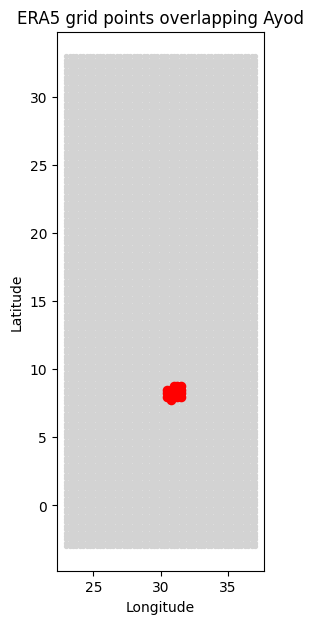

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

ayod_gdf = gpd.GeoDataFrame(
    [ayod],
    geometry="geometry",
    crs=admin2.crs
)

ayod_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

era5_grid.plot(
    ax=ax,
    markersize=8,
    color="lightgray"
)

ayod_overlapping.plot(
    ax=ax,
    markersize=35,
    color="red"
)

ax.set_title("ERA5 grid points overlapping Ayod")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [12]:
admin_to_era5 = {}

for _, area in admin2.iterrows():
    points_inside = era5_grid[
        era5_grid.geometry.within(area.geometry)
    ]

    admin_to_era5[area["adm2_name"]] = points_inside.index.tolist()

# Summary
n_cells = pd.Series({
    area: len(indices)
    for area, indices in admin_to_era5.items()
})

print("Number of ERA5 grid points per administrative area:")
print(n_cells.describe())

print("\nAreas with no ERA5 grid points:")
print(n_cells[n_cells == 0])

print("\nAyod:")
print(n_cells["Ayod"])

Number of ERA5 grid points per administrative area:
count    79.000000
mean     10.607595
std      10.629444
min       0.000000
25%       6.000000
50%       8.000000
75%      12.000000
max      80.000000
dtype: float64

Areas with no ERA5 grid points:
Malakal    0
dtype: int64

Ayod:
19


In [13]:
malakal = admin2[admin2["adm2_name"] == "Malakal"].iloc[0]

print("Malakal area:", malakal["area_sqkm"], "km²")
print("Malakal bounds:", malakal.geometry.bounds)
print("Malakal centroid:", malakal.geometry.centroid)

Malakal area: 754.68040964 km²
Malakal bounds: (31.365995769000108, 9.446234659000083, 31.86756460900017, 9.898903704000077)
Malakal centroid: POINT (31.64279686743318 9.658456964478876)


In [14]:
from shapely.geometry import Polygon

lat_values = rainfall_runoff.latitude.values
lon_values = rainfall_runoff.longitude.values

# Calculate grid-cell boundaries from the midpoints between grid centres
lat_edges = np.empty(len(lat_values) + 1)
lon_edges = np.empty(len(lon_values) + 1)

lat_edges[1:-1] = (lat_values[:-1] + lat_values[1:]) / 2
lon_edges[1:-1] = (lon_values[:-1] + lon_values[1:]) / 2

# Extend the outer boundaries by half a grid spacing
lat_edges[0] = lat_values[0] + (lat_values[0] - lat_values[1]) / 2
lat_edges[-1] = lat_values[-1] + (lat_values[-1] - lat_values[-2]) / 2

lon_edges[0] = lon_values[0] - (lon_values[1] - lon_values[0]) / 2
lon_edges[-1] = lon_values[-1] + (lon_values[-1] - lon_values[-2]) / 2

grid_cells = []

for i, lat in enumerate(lat_values):
    for j, lon in enumerate(lon_values):
        cell = Polygon([
            (lon_edges[j],     lat_edges[i]),
            (lon_edges[j + 1], lat_edges[i]),
            (lon_edges[j + 1], lat_edges[i + 1]),
            (lon_edges[j],     lat_edges[i + 1])
        ])

        grid_cells.append({
            "lat_idx": i,
            "lon_idx": j,
            "latitude": lat,
            "longitude": lon,
            "geometry": cell
        })

era5_cells = gpd.GeoDataFrame(
    grid_cells,
    crs="EPSG:4326"
)

print("Number of ERA5 grid cells:", len(era5_cells))
print("Expected:", len(lat_values) * len(lon_values))

Number of ERA5 grid cells: 8265
Expected: 8265


In [15]:
malakal_cells = era5_cells[
    era5_cells.geometry.intersects(malakal.geometry)
]

print("ERA5 grid cells overlapping Malakal:", len(malakal_cells))

print("\nOverlapping grid cells:")
print(
    malakal_cells[
        ["latitude", "longitude"]
    ].to_string(index=False)
)

ERA5 grid cells overlapping Malakal: 6

Overlapping grid cells:
 latitude  longitude
    10.00      31.50
     9.75      31.25
     9.75      31.50
     9.75      31.75
     9.50      31.50
     9.50      31.75


In [16]:
admin_to_era5 = {}

for _, area in admin2.iterrows():
    overlapping_cells = era5_cells[
        era5_cells.geometry.intersects(area.geometry)
    ]

    admin_to_era5[area["adm2_name"]] = overlapping_cells.index.tolist()

# Number of ERA5 cells per administrative area
n_cells = pd.Series({
    area: len(indices)
    for area, indices in admin_to_era5.items()
})

print("ERA5 cells per administrative area:")
print(n_cells.describe())

print("\nAreas with no overlapping ERA5 cells:")
print(n_cells[n_cells == 0])

print("\nSelected areas:")
print(n_cells[["Ayod", "Malakal"]])

ERA5 cells per administrative area:
count     79.000000
mean      20.873418
std       14.178683
min        6.000000
25%       14.000000
50%       17.000000
75%       26.000000
max      112.000000
dtype: float64

Areas with no overlapping ERA5 cells:
Series([], dtype: int64)

Selected areas:
Ayod       29
Malakal     6
dtype: int64


In [17]:
# Use an equal-area CRS so overlap areas are comparable
admin_equal_area = admin2.to_crs("EPSG:6933")
era5_cells_equal_area = era5_cells.to_crs("EPSG:6933")

admin_to_era5_weights = {}

for _, area in admin_equal_area.iterrows():

    overlapping = era5_cells_equal_area[
        era5_cells_equal_area.geometry.intersects(area.geometry)
    ].copy()

    # Calculate the actual intersection area
    overlapping["intersection_area"] = overlapping.geometry.intersection(
        area.geometry
    ).area

    # Keep only positive overlaps
    overlapping = overlapping[
        overlapping["intersection_area"] > 0
    ].copy()

    # Normalize so weights sum to 1 within each administrative area
    overlapping["weight"] = (
        overlapping["intersection_area"]
        / overlapping["intersection_area"].sum()
    )

    admin_to_era5_weights[area["adm2_name"]] = overlapping[
        ["lat_idx", "lon_idx", "latitude", "longitude", "weight"]
    ].reset_index(drop=True)

print("Ayod:")
print(admin_to_era5_weights["Ayod"])

print("\nMalakal:")
print(admin_to_era5_weights["Malakal"])

Ayod:
    lat_idx  lon_idx  latitude  longitude    weight
0        97       30      8.75      30.50  0.003920
1        97       31      8.75      30.75  0.016593
2        97       32      8.75      31.00  0.042475
3        97       33      8.75      31.25  0.043821
4        97       34      8.75      31.50  0.019403
5        98       29      8.50      30.25  0.006918
6        98       30      8.50      30.50  0.054889
7        98       31      8.50      30.75  0.056590
8        98       32      8.50      31.00  0.056590
9        98       33      8.50      31.25  0.056590
10       98       34      8.50      31.50  0.043562
11       98       35      8.50      31.75  0.005071
12       99       29      8.25      30.25  0.008507
13       99       30      8.25      30.50  0.056626
14       99       31      8.25      30.75  0.056626
15       99       32      8.25      31.00  0.056626
16       99       33      8.25      31.25  0.056626
17       99       34      8.25      31.50  0.051138
18    

In [18]:
weight_sums = pd.Series({
    area: weights["weight"].sum()
    for area, weights in admin_to_era5_weights.items()
})

print("Weight sums:")
print(weight_sums.describe())

print("\nAreas where weights do not sum to 1:")
print(weight_sums[~np.isclose(weight_sums, 1.0)])

print("\nNumber of cells used:")
print(pd.Series({
    area: len(weights)
    for area, weights in admin_to_era5_weights.items()
}).describe())

Weight sums:
count    7.900000e+01
mean     1.000000e+00
std      1.269589e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Areas where weights do not sum to 1:
Series([], dtype: float64)

Number of cells used:
count     79.000000
mean      20.873418
std       14.178683
min        6.000000
25%       14.000000
50%       17.000000
75%       26.000000
max      112.000000
dtype: float64


In [19]:
# Load the ERA5 variables into memory once
tp_data = rainfall_runoff["tp"].compute().values
ro_data = rainfall_runoff["ro"].compute().values

print("ERA5 arrays loaded:")
print("Precipitation shape:", tp_data.shape)
print("Runoff shape:", ro_data.shape)

area_weather = {}

dates = pd.to_datetime(rainfall_runoff.valid_time.values)

for area_name, weights in admin_to_era5_weights.items():

    tp_values = tp_data[
        :,
        weights["lat_idx"].values,
        weights["lon_idx"].values
    ]

    ro_values = ro_data[
        :,
        weights["lat_idx"].values,
        weights["lon_idx"].values
    ]

    w = weights["weight"].values

    # Area-weighted mean
    tp_area = np.sum(tp_values * w[None, :], axis=1)
    ro_area = np.sum(ro_values * w[None, :], axis=1)

    area_weather[area_name] = pd.DataFrame({
        "date": dates,
        "precipitation_m": tp_area,
        "runoff_m": ro_area
    }).set_index("date")

print("\nFinished.")
print("Number of areas:", len(area_weather))
print("\nAyod:")
print(area_weather["Ayod"].head())

ERA5 arrays loaded:
Precipitation shape: (366, 145, 57)
Runoff shape: (366, 145, 57)

Finished.
Number of areas: 79

Ayod:
            precipitation_m  runoff_m
date                                 
2020-01-01              0.0       0.0
2020-01-02              0.0       0.0
2020-01-03              0.0       0.0
2020-01-04              0.0       0.0
2020-01-05              0.0       0.0


In [20]:
print("Ayod shape:", area_weather["Ayod"].shape)

print("\nDate range:")
print(
    area_weather["Ayod"].index.min(),
    "to",
    area_weather["Ayod"].index.max()
)

print("\nMissing values:")
print(area_weather["Ayod"].isna().sum())

print("\nAyod summary:")
print(area_weather["Ayod"].describe())

Ayod shape: (366, 2)

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Missing values:
precipitation_m    0
runoff_m           0
dtype: int64

Ayod summary:
       precipitation_m    runoff_m
count       366.000000  366.000000
mean          0.002238    0.000116
std           0.004551    0.000407
min           0.000000    0.000000
25%           0.000000    0.000000
50%           0.000204    0.000001
75%           0.002237    0.000021
max           0.040337    0.003321


In [21]:
for area_name in area_weather:
    area_weather[area_name]["precipitation_mm"] = (
        area_weather[area_name]["precipitation_m"] * 1000
    )

    area_weather[area_name]["runoff_mm"] = (
        area_weather[area_name]["runoff_m"] * 1000
    )

print(area_weather["Ayod"].head())

print("\nAyod precipitation summary (mm):")
print(area_weather["Ayod"]["precipitation_mm"].describe())

            precipitation_m  runoff_m  precipitation_mm  runoff_mm
date                                                              
2020-01-01              0.0       0.0               0.0        0.0
2020-01-02              0.0       0.0               0.0        0.0
2020-01-03              0.0       0.0               0.0        0.0
2020-01-04              0.0       0.0               0.0        0.0
2020-01-05              0.0       0.0               0.0        0.0

Ayod precipitation summary (mm):
count    366.000000
mean       2.238413
std        4.550820
min        0.000000
25%        0.000000
50%        0.203823
75%        2.236538
max       40.336581
Name: precipitation_mm, dtype: float64


In [22]:
for area_name in area_weather:
    
    df = area_weather[area_name]

    for window in [3, 7, 14]:
        df[f"precip_{window}d_mm"] = (
            df["precipitation_mm"]
            .rolling(window=window, min_periods=window)
            .sum()
        )

        df[f"runoff_{window}d_mm"] = (
            df["runoff_mm"]
            .rolling(window=window, min_periods=window)
            .sum()
        )

print(area_weather["Ayod"].head(16))

            precipitation_m  runoff_m  precipitation_mm  runoff_mm  \
date                                                                 
2020-01-01              0.0       0.0               0.0        0.0   
2020-01-02              0.0       0.0               0.0        0.0   
2020-01-03              0.0       0.0               0.0        0.0   
2020-01-04              0.0       0.0               0.0        0.0   
2020-01-05              0.0       0.0               0.0        0.0   
2020-01-06              0.0       0.0               0.0        0.0   
2020-01-07              0.0       0.0               0.0        0.0   
2020-01-08              0.0       0.0               0.0        0.0   
2020-01-09              0.0       0.0               0.0        0.0   
2020-01-10              0.0       0.0               0.0        0.0   
2020-01-11              0.0       0.0               0.0        0.0   
2020-01-12              0.0       0.0               0.0        0.0   
2020-01-13          

In [23]:
ayod_weather = area_weather["Ayod"]

print("Days with zero precipitation:")
print(
    (ayod_weather["precipitation_mm"] == 0).sum(),
    "of",
    len(ayod_weather)
)

print("\nDays with precipitation > 0:")
print(
    (ayod_weather["precipitation_mm"] > 0).sum(),
    "of",
    len(ayod_weather)
)

print("\nPrecipitation quantiles (mm):")
print(
    ayod_weather["precipitation_mm"].quantile(
        [0, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

print("\n7-day accumulated precipitation quantiles (mm):")
print(
    ayod_weather["precip_7d_mm"].quantile(
        [0, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

Days with zero precipitation:
125 of 366

Days with precipitation > 0:
241 of 366

Precipitation quantiles (mm):
0.00     0.000000
0.50     0.203823
0.75     2.236538
0.90     7.520531
0.95    11.180993
0.99    20.663704
1.00    40.336581
Name: precipitation_mm, dtype: float64

7-day accumulated precipitation quantiles (mm):
0.00     0.000000
0.50     5.981235
0.75    30.015957
0.90    47.240916
0.95    53.870468
0.99    70.296177
1.00    76.685228
Name: precip_7d_mm, dtype: float64


In [24]:
monthly_weather = ayod_weather[
    ["precipitation_mm", "runoff_mm"]
].resample("ME").sum()

print(monthly_weather)

            precipitation_mm  runoff_mm
date                                   
2020-01-31          0.000000   0.000000
2020-02-29          0.043681   0.000003
2020-03-31          4.011512   0.021956
2020-04-30          5.263697   0.024507
2020-05-31         69.919811   0.942422
2020-06-30         95.097390   2.736476
2020-07-31        203.307283   9.623129
2020-08-31        197.062368  16.823640
2020-09-30        147.104324   8.182516
2020-10-31         92.625116   3.936636
2020-11-30          4.763420   0.049431
2020-12-31          0.060639   0.000108


In [25]:
from processing_data.loading import load_flood_masks

flood_2020 = load_flood_masks(np.array([2020]))

print("Shape:", flood_2020.shape)
print("\nColumns:")
print(flood_2020.columns.tolist())

print("\nFirst rows:")
print(flood_2020.head())

Shape: (4765044, 5)

Columns:
['date', 'lat', 'lon', 'tile', 'flood_type']

First rows:
        date       lat        lon    tile  flood_type
0 2020-01-01  0.003125  32.226040  h21v08           1
1 2020-01-01  0.034375  32.265625  h21v08           0
2 2020-01-01  0.086458  33.488541  h21v08           0
3 2020-01-01  0.096875  32.709373  h21v08           0
4 2020-01-01  0.136458  33.801041  h21v08           0


In [26]:
print("Flood type values:")
print(flood_2020["flood_type"].value_counts(dropna=False).sort_index())

print("\nFlood type proportions:")
print(
    flood_2020["flood_type"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
)

print("\nDate range:")
print(flood_2020["date"].min(), "to", flood_2020["date"].max())

print("\nUnique dates:", flood_2020["date"].nunique())
print("Unique tiles:", flood_2020["tile"].nunique())

Flood type values:
flood_type
0    1659528
1    3105516
Name: count, dtype: int64

Flood type proportions:
flood_type
0    0.348271
1    0.651729
Name: proportion, dtype: float64

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Unique dates: 364
Unique tiles: 2


In [27]:
all_dates_2020 = pd.date_range("2020-01-01", "2020-12-31", freq="D")
flood_dates_2020 = pd.DatetimeIndex(flood_2020["date"].unique())

missing_flood_dates = all_dates_2020.difference(flood_dates_2020)

print("Missing flood-observation dates:")
print(missing_flood_dates.tolist())

print("\nNumber missing:", len(missing_flood_dates))

Missing flood-observation dates:
[Timestamp('2020-08-21 00:00:00'), Timestamp('2020-08-31 00:00:00')]

Number missing: 2


In [28]:
print("Latitude range:")
print(flood_2020["lat"].min(), "to", flood_2020["lat"].max())

print("\nLongitude range:")
print(flood_2020["lon"].min(), "to", flood_2020["lon"].max())

print("\nObservations per date:")
print(
    flood_2020.groupby("date")
    .size()
    .describe()
)

print("\nObservations by flood type:")
print(
    flood_2020.groupby("flood_type")
    .size()
)

Latitude range:
0.0010416667 to 9.998959

Longitude range:
20.001041 to 39.99896

Observations per date:
count      364.000000
mean     13090.780220
std      12932.336182
min         50.000000
25%       3340.250000
50%       7716.500000
75%      20563.750000
max      54769.000000
dtype: float64

Observations by flood type:
flood_type
0    1659528
1    3105516
dtype: int64


In [29]:
# Convert flood observations to a GeoDataFrame
flood_points = gpd.GeoDataFrame(
    flood_2020.copy(),
    geometry=gpd.points_from_xy(
        flood_2020["lon"],
        flood_2020["lat"]
    ),
    crs="EPSG:4326"
)

# Spatially assign each observation to an admin2 area
flood_with_admin2 = gpd.sjoin(
    flood_points,
    admin2[["adm2_name", "geometry"]],
    how="inner",
    predicate="within"
)

print("Original observations:", len(flood_points))
print("Observations inside admin2:", len(flood_with_admin2))

print("\nAdmin2 areas represented:")
print(flood_with_admin2["adm2_name"].nunique())

print("\nExample:")
print(flood_with_admin2.head())

Original observations: 4765044
Observations inside admin2: 2486195

Admin2 areas represented:
77

Example:
           date       lat        lon    tile  flood_type  \
4715 2020-01-01  4.434375  31.498959  h21v08           0   
4716 2020-01-01  4.434375  31.501041  h21v08           0   
4724 2020-01-01  4.436458  31.503124  h21v08           0   
4732 2020-01-01  4.438542  31.507292  h21v08           1   
5398 2020-01-01  4.836458  32.109375  h21v08           1   

                      geometry  index_right adm2_name  
4715  POINT (31.49896 4.43437)            0      Juba  
4716  POINT (31.50104 4.43437)            0      Juba  
4724  POINT (31.50312 4.43646)            0      Juba  
4732  POINT (31.50729 4.43854)            0      Juba  
5398  POINT (32.10938 4.83646)            0      Juba  


In [30]:
daily_flood = (
    flood_with_admin2
    .groupby(["adm2_name", "date"])
    .agg(
        flood_observations=("flood_type", "size"),
        flooded_observations=("flood_type", "sum")
    )
    .reset_index()
)

daily_flood["flood_observation_fraction"] = (
    daily_flood["flooded_observations"]
    / daily_flood["flood_observations"]
)

print(daily_flood.head())

print("\nShape:", daily_flood.shape)

print("\nFraction summary:")
print(
    daily_flood["flood_observation_fraction"]
    .describe()
)

   adm2_name       date  flood_observations  flooded_observations  \
0  Abiemnhom 2020-01-05                   1                     1   
1  Abiemnhom 2020-01-10                   1                     1   
2  Abiemnhom 2020-01-12                   4                     4   
3  Abiemnhom 2020-01-14                   4                     4   
4  Abiemnhom 2020-01-21                   2                     2   

   flood_observation_fraction  
0                         1.0  
1                         1.0  
2                         1.0  
3                         1.0  
4                         1.0  

Shape: (7231, 5)

Fraction summary:
count    7231.000000
mean        0.683146
std         0.360828
min         0.000000
25%         0.384615
50%         0.855297
75%         1.000000
max         1.000000
Name: flood_observation_fraction, dtype: float64


In [31]:
print("Daily observation-count distribution:")
print(
    daily_flood["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nNumber of admin2-day records by observation count:")
print(
    daily_flood["flood_observations"]
    .value_counts()
    .sort_index()
    .head(20)
)

Daily observation-count distribution:
count     7231.000000
mean       343.824506
std       1682.757442
min          1.000000
25%          5.000000
50%         29.000000
75%        142.000000
90%        550.000000
95%       1216.500000
99%       5084.700000
max      29292.000000
Name: flood_observations, dtype: float64

Number of admin2-day records by observation count:
flood_observations
1     649
2     441
3     315
4     245
5     199
6     164
7     159
8     144
9     118
10    102
11     96
12     95
13     89
14     65
15     65
16     68
17     48
18     68
19     76
20     46
Name: count, dtype: int64


In [32]:
print("Daily observation-count distribution:")
print(
    daily_flood["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nNumber of admin2-day records by observation count:")
print(
    daily_flood["flood_observations"]
    .value_counts()
    .sort_index()
    .head(20)
)

Daily observation-count distribution:
count     7231.000000
mean       343.824506
std       1682.757442
min          1.000000
25%          5.000000
50%         29.000000
75%        142.000000
90%        550.000000
95%       1216.500000
99%       5084.700000
max      29292.000000
Name: flood_observations, dtype: float64

Number of admin2-day records by observation count:
flood_observations
1     649
2     441
3     315
4     245
5     199
6     164
7     159
8     144
9     118
10    102
11     96
12     95
13     89
14     65
15     65
16     68
17     48
18     68
19     76
20     46
Name: count, dtype: int64


In [33]:
area_obs_summary = (
    daily_flood
    .groupby("adm2_name")
    .agg(
        days_with_observations=("date", "nunique"),
        total_observations=("flood_observations", "sum"),
        median_daily_observations=("flood_observations", "median")
    )
    .sort_values("days_with_observations")
)

print(area_obs_summary.head(15))

               days_with_observations  total_observations  \
adm2_name                                                   
Morobo                              2                   4   
Kapoeta South                       4                  12   
Nzara                               6                  24   
Tambura                             6                  46   
Lainya                             10                  67   
Mundri West                        11                 107   
Mundri East                        12                 182   
Ibba                               13                 118   
Maridi                             13                 135   
Abyei Region                       14                  35   
Yambio                             14                  74   
Kapoeta North                      15                  53   
Yei                                15                 165   
Kajo-keji                          15                  36   
Raja                    

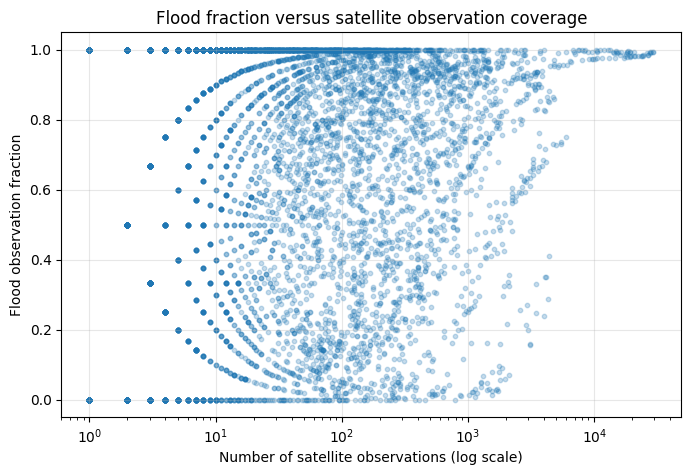

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_flood["flood_observations"],
    daily_flood["flood_observation_fraction"],
    alpha=0.25,
    s=10
)

plt.xscale("log")
plt.xlabel("Number of satellite observations (log scale)")
plt.ylabel("Flood observation fraction")
plt.title("Flood fraction versus satellite observation coverage")
plt.grid(alpha=0.3)

plt.show()

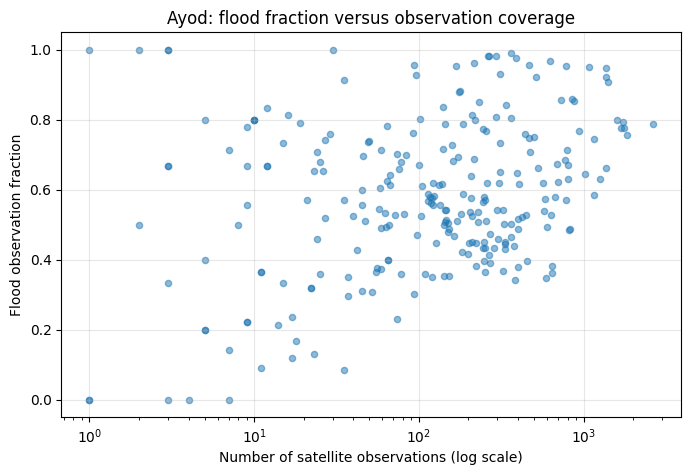

In [35]:
ayod_flood = daily_flood[
    daily_flood["adm2_name"] == "Ayod"
].copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    ayod_flood["flood_observations"],
    ayod_flood["flood_observation_fraction"],
    alpha=0.5,
    s=20
)

plt.xscale("log")
plt.xlabel("Number of satellite observations (log scale)")
plt.ylabel("Flood observation fraction")
plt.title("Ayod: flood fraction versus observation coverage")
plt.grid(alpha=0.3)

plt.show()

In [36]:
coverage_thresholds = [1, 5, 10, 25, 50, 100, 250, 500]

coverage_sensitivity = []

for threshold in coverage_thresholds:
    subset = daily_flood[
        daily_flood["flood_observations"] >= threshold
    ]

    coverage_sensitivity.append({
        "minimum_observations": threshold,
        "admin2_days_retained": len(subset),
        "percent_retained": 100 * len(subset) / len(daily_flood),
        "admin2_areas_retained": subset["adm2_name"].nunique()
    })

coverage_sensitivity = pd.DataFrame(coverage_sensitivity)

print(coverage_sensitivity)

   minimum_observations  admin2_days_retained  percent_retained  \
0                     1                  7231        100.000000   
1                     5                  5581         77.181579   
2                    10                  4797         66.339372   
3                    25                  3794         52.468538   
4                    50                  2996         41.432720   
5                   100                  2172         30.037339   
6                   250                  1283         17.743051   
7                   500                   782         10.814548   

   admin2_areas_retained  
0                     77  
1                     76  
2                     73  
3                     67  
4                     60  
5                     48  
6                     42  
7                     32  


In [37]:
for threshold in [5, 10, 25, 50, 100]:
    subset = daily_flood[
        daily_flood["flood_observations"] >= threshold
    ]

    print(
        f"Minimum {threshold:>3} observations: "
        f"{subset['adm2_name'].nunique():>2} admin2 areas"
    )

Minimum   5 observations: 76 admin2 areas
Minimum  10 observations: 73 admin2 areas
Minimum  25 observations: 67 admin2 areas
Minimum  50 observations: 60 admin2 areas
Minimum 100 observations: 48 admin2 areas


In [38]:
MIN_OBSERVATIONS = 5

daily_flood_primary = daily_flood[
    daily_flood["flood_observations"] >= MIN_OBSERVATIONS
].copy()

print("Primary flood dataset:")
print("Rows:", len(daily_flood_primary))
print("Admin2 areas:", daily_flood_primary["adm2_name"].nunique())

print("\nObservation count:")
print(
    daily_flood_primary["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]
    )
)

print("\nFlood fraction:")
print(
    daily_flood_primary["flood_observation_fraction"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Primary flood dataset:
Rows: 5581
Admin2 areas: 76

Observation count:
count     5581.000000
mean       444.855581
std       1903.747402
min          5.000000
25%         17.000000
50%         59.000000
75%        219.000000
90%        766.000000
95%       1526.000000
max      29292.000000
Name: flood_observations, dtype: float64

Flood fraction:
count    5581.000000
mean        0.686584
std         0.335214
min         0.000000
10%         0.133333
25%         0.422222
50%         0.818182
75%         1.000000
90%         1.000000
95%         1.000000
max         1.000000
Name: flood_observation_fraction, dtype: float64


In [39]:
area_flood_summary = (
    daily_flood_primary
    .groupby("adm2_name")["flood_observation_fraction"]
    .agg(
        days="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        max="max"
    )
    .sort_values("median", ascending=False)
)

print(area_flood_summary.head(15))
print("\n...")
print(area_flood_summary.tail(15))

              days      mean  median  p75  p90  max
adm2_name                                          
Abiemnhom        7  1.000000     1.0  1.0  1.0  1.0
Abyei Region     2  1.000000     1.0  1.0  1.0  1.0
Magwi            9  0.971781     1.0  1.0  1.0  1.0
Maban           48  0.999907     1.0  1.0  1.0  1.0
Maridi           8  1.000000     1.0  1.0  1.0  1.0
Ikotos          12  1.000000     1.0  1.0  1.0  1.0
Kapoeta East   128  0.998177     1.0  1.0  1.0  1.0
Ibba             3  1.000000     1.0  1.0  1.0  1.0
Ezo              7  1.000000     1.0  1.0  1.0  1.0
Cueibet         97  0.957382     1.0  1.0  1.0  1.0
Canal/Pigi      95  0.978530     1.0  1.0  1.0  1.0
Budi            16  1.000000     1.0  1.0  1.0  1.0
Wulu            45  0.986135     1.0  1.0  1.0  1.0
Tambura          2  1.000000     1.0  1.0  1.0  1.0
Tonj East       51  1.000000     1.0  1.0  1.0  1.0

...
              days      mean    median       p75       p90       max
adm2_name                                 

In [40]:
daily_flood_detail = (
    flood_with_admin2
    .groupby(["adm2_name", "date"])
    .agg(
        flood_observations=("flood_type", "size"),
        recurring_observations=("flood_type", lambda x: (x == 0).sum()),
        unusual_observations=("flood_type", lambda x: (x == 1).sum())
    )
    .reset_index()
)

daily_flood_detail["recurring_fraction"] = (
    daily_flood_detail["recurring_observations"]
    / daily_flood_detail["flood_observations"]
)

daily_flood_detail["unusual_fraction"] = (
    daily_flood_detail["unusual_observations"]
    / daily_flood_detail["flood_observations"]
)

print(daily_flood_detail.head())

print("\nSummary:")
print(
    daily_flood_detail[
        [
            "flood_observations",
            "recurring_fraction",
            "unusual_fraction"
        ]
    ].describe()
)

   adm2_name       date  flood_observations  recurring_observations  \
0  Abiemnhom 2020-01-05                   1                       0   
1  Abiemnhom 2020-01-10                   1                       0   
2  Abiemnhom 2020-01-12                   4                       0   
3  Abiemnhom 2020-01-14                   4                       0   
4  Abiemnhom 2020-01-21                   2                       0   

   unusual_observations  recurring_fraction  unusual_fraction  
0                     1                 0.0               1.0  
1                     1                 0.0               1.0  
2                     4                 0.0               1.0  
3                     4                 0.0               1.0  
4                     2                 0.0               1.0  

Summary:
       flood_observations  recurring_fraction  unusual_fraction
count         7231.000000         7231.000000       7231.000000
mean           343.824506            0.316854      

In [41]:
MIN_OBSERVATIONS = 5

daily_flood_primary = daily_flood_detail[
    daily_flood_detail["flood_observations"] >= MIN_OBSERVATIONS
].copy()

print("Rows:", len(daily_flood_primary))
print("Admin2 areas:", daily_flood_primary["adm2_name"].nunique())

print("\nUnusual-flood fraction:")
print(
    daily_flood_primary["unusual_fraction"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Rows: 5581
Admin2 areas: 76

Unusual-flood fraction:
count    5581.000000
mean        0.686584
std         0.335214
min         0.000000
10%         0.133333
25%         0.422222
50%         0.818182
75%         1.000000
90%         1.000000
95%         1.000000
max         1.000000
Name: unusual_fraction, dtype: float64


In [42]:
ayod_flood = daily_flood_primary[
    daily_flood_primary["adm2_name"] == "Ayod"
].copy()

print(
    ayod_flood[
        [
            "date",
            "flood_observations",
            "recurring_fraction",
            "unusual_fraction"
        ]
    ].head(20)
)

print("\nAyod unusual-flood fraction:")
print(
    ayod_flood["unusual_fraction"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

          date  flood_observations  recurring_fraction  unusual_fraction
709 2020-01-01                 138            0.384058          0.615942
710 2020-01-02                 179            0.469274          0.530726
711 2020-01-03                 114            0.412281          0.587719
712 2020-01-04                  35            0.428571          0.571429
713 2020-01-05                  40            0.475000          0.525000
714 2020-01-07                 210            0.476190          0.523810
715 2020-01-09                 146            0.458904          0.541096
716 2020-01-10                 150            0.520000          0.480000
717 2020-01-11                 245            0.567347          0.432653
718 2020-01-12                 385            0.657143          0.342857
719 2020-01-13                 221            0.552036          0.447964
720 2020-01-14                 643            0.637636          0.362364
721 2020-01-15                 144            0.458

In [43]:
daily_flood_primary = daily_flood_detail[
    daily_flood_detail["flood_observations"] >= 5
].copy()

# Spatially normalize detected flood pixels by admin2 area
area_lookup = admin2[["adm2_name", "area_sqkm"]].copy()

daily_flood_primary = daily_flood_primary.merge(
    area_lookup,
    on="adm2_name",
    how="left"
)

daily_flood_primary["unusual_observations_per_km2"] = (
    daily_flood_primary["unusual_observations"]
    / daily_flood_primary["area_sqkm"]
)

daily_flood_primary["recurring_observations_per_km2"] = (
    daily_flood_primary["recurring_observations"]
    / daily_flood_primary["area_sqkm"]
)

print(
    daily_flood_primary[
        [
            "adm2_name",
            "date",
            "flood_observations",
            "unusual_observations",
            "recurring_observations",
            "unusual_fraction",
            "unusual_observations_per_km2"
        ]
    ].head()
)

   adm2_name       date  flood_observations  unusual_observations  \
0  Abiemnhom 2020-01-28                   5                     5   
1  Abiemnhom 2020-01-30                   5                     5   
2  Abiemnhom 2020-02-03                   8                     8   
3  Abiemnhom 2020-02-04                   9                     9   
4  Abiemnhom 2020-02-06                  11                    11   

   recurring_observations  unusual_fraction  unusual_observations_per_km2  
0                       0               1.0                      0.002077  
1                       0               1.0                      0.002077  
2                       0               1.0                      0.003322  
3                       0               1.0                      0.003738  
4                       0               1.0                      0.004568  


In [44]:
ayod_flood = daily_flood_primary[
    daily_flood_primary["adm2_name"] == "Ayod"
].copy()

print("Ayod unusual observations:")
print(
    ayod_flood["unusual_observations"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nAyod unusual observations per km²:")
print(
    ayod_flood["unusual_observations_per_km2"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Ayod unusual observations:
count     241.000000
mean      198.290456
std       304.711952
min         0.000000
25%        28.000000
50%        89.000000
75%       205.000000
90%       507.000000
95%       795.000000
99%      1365.000000
max      2080.000000
Name: unusual_observations, dtype: float64

Ayod unusual observations per km²:
count    241.000000
mean       0.014744
std        0.022657
min        0.000000
25%        0.002082
50%        0.006618
75%        0.015243
90%        0.037698
95%        0.059112
99%        0.101493
max        0.154657
Name: unusual_observations_per_km2, dtype: float64


In [45]:
ayod_flood = daily_flood_primary[
    daily_flood_primary["adm2_name"] == "Ayod"
].copy()

print("Ayod unusual observations:")
print(
    ayod_flood["unusual_observations"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nAyod unusual observations per km²:")
print(
    ayod_flood["unusual_observations_per_km2"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Ayod unusual observations:
count     241.000000
mean      198.290456
std       304.711952
min         0.000000
25%        28.000000
50%        89.000000
75%       205.000000
90%       507.000000
95%       795.000000
99%      1365.000000
max      2080.000000
Name: unusual_observations, dtype: float64

Ayod unusual observations per km²:
count    241.000000
mean       0.014744
std        0.022657
min        0.000000
25%        0.002082
50%        0.006618
75%        0.015243
90%        0.037698
95%        0.059112
99%        0.101493
max        0.154657
Name: unusual_observations_per_km2, dtype: float64


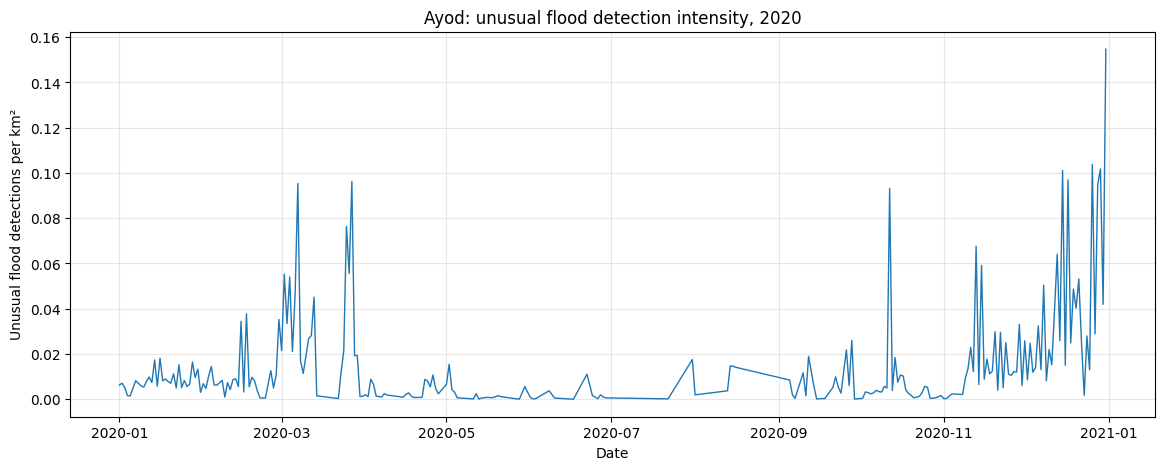

In [46]:
ayod_flood_plot = (
    daily_flood_primary[
        daily_flood_primary["adm2_name"] == "Ayod"
    ][
        [
            "date",
            "unusual_observations",
            "unusual_observations_per_km2"
        ]
    ]
    .sort_values("date")
)

plt.figure(figsize=(14, 5))

plt.plot(
    ayod_flood_plot["date"],
    ayod_flood_plot["unusual_observations_per_km2"],
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Unusual flood detections per km²")
plt.title("Ayod: unusual flood detection intensity, 2020")
plt.grid(alpha=0.3)

plt.show()

In [91]:

ayod_compare = ayod_weather.copy()

# Join the unusual-detection series
ayod_compare = ayod_compare.join(
    ayod_flood_plot.set_index("date")[
        ["unusual_observations_per_km2"]
    ],
    how="left"
)

# Identify dates with no detections anywhere in the study areas
all_detection_dates = pd.DatetimeIndex(
    pd.to_datetime(daily_flood_detail["date"]).unique()
).normalize()

ayod_compare.index = pd.to_datetime(ayod_compare.index).normalize()

no_detections_anywhere = ~ayod_compare.index.isin(
    all_detection_dates
)

# Missing Ayod records on dates with detections elsewhere:
# set to zero recorded unusual detections, with the caveat that
# this does not prove the area was observed adequately.
ayod_compare.loc[
    ~no_detections_anywhere
    & ayod_compare["unusual_observations_per_km2"].isna(),
    "unusual_observations_per_km2"
] = 0

# Keep product-wide no-detection dates as missing, not zero
ayod_compare.loc[
    no_detections_anywhere,
    "unusual_observations_per_km2"
] = np.nan

print("Dates in weather series:", len(ayod_compare))
print(
    "Dates with recorded unusual detections:",
    ayod_compare["unusual_observations_per_km2"].notna().sum()
    - ayod_compare.loc[no_detections_anywhere,
                       "unusual_observations_per_km2"].notna().sum()
)
print(
    "Dates with no detections anywhere:",
    no_detections_anywhere.sum()
)
print(
    "Dates still missing after this treatment:",
    ayod_compare["unusual_observations_per_km2"].isna().sum()
)


Dates in weather series: 366
Dates with recorded unusual detections: 331
Dates with no detections anywhere: 35
Dates still missing after this treatment: 35


In [92]:
# Diagnose missing flood records before interpreting them as zero

print("Ayod weather date range:")
print(ayod_weather.index.min(), "to", ayod_weather.index.max())

print("\nNumber of weather dates:", len(ayod_weather))
print(
    "Dates with unusual detections:",
    ayod_flood_plot["date"].nunique()
)

print(
    "Dates with positive unusual detections:",
    (ayod_flood_plot["unusual_observations_per_km2"] > 0).sum()
)

print(
    "Dates currently represented as zero in comparison:",
    (ayod_compare["unusual_observations_per_km2"] == 0).sum()
)

Ayod weather date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Number of weather dates: 366
Dates with unusual detections: 241
Dates with positive unusual detections: 240
Dates currently represented as zero in comparison: 91


In [93]:
# Identify dates missing from the Ayod flood-detection data

weather_dates = pd.DatetimeIndex(ayod_weather.index).normalize()
flood_dates = pd.DatetimeIndex(
    pd.to_datetime(ayod_flood_plot["date"])
).normalize().unique()

missing_flood_dates = weather_dates.difference(flood_dates)

print("Missing flood-record dates:", len(missing_flood_dates))
print("\nFirst 30 missing dates:")
print(missing_flood_dates[:30])

# Check whether missing dates occur in consecutive runs
missing_series = pd.Series(
    missing_flood_dates.sort_values()
)

if not missing_series.empty:
    gaps = missing_series.diff().dt.days
    print("\nLargest gaps between missing dates (days):")
    print(gaps.sort_values(ascending=False).head(10))

Missing flood-record dates: 125

First 30 missing dates:
DatetimeIndex(['2020-01-06', '2020-01-08', '2020-02-07', '2020-02-23',
               '2020-02-25', '2020-03-10', '2020-03-15', '2020-03-16',
               '2020-03-17', '2020-03-18', '2020-03-19', '2020-03-20',
               '2020-03-21', '2020-04-06', '2020-04-10', '2020-04-11',
               '2020-04-12', '2020-04-13', '2020-04-14', '2020-04-20',
               '2020-04-21', '2020-04-29', '2020-04-30', '2020-05-06',
               '2020-05-07', '2020-05-08', '2020-05-09', '2020-05-10',
               '2020-05-15', '2020-05-17'],
              dtype='datetime64[ns]', name='date', freq=None)

Largest gaps between missing dates (days):
2      30.0
121    19.0
13     16.0
3      16.0
5      14.0
123    12.0
21      8.0
23      6.0
19      6.0
116     6.0
Name: date, dtype: float64


In [94]:
# Compare missing Ayod dates with dates that have detections elsewhere

all_detection_dates = pd.DatetimeIndex(
    pd.to_datetime(daily_flood_detail["date"]).unique()
).normalize()

ayod_missing_with_anywhere = missing_flood_dates.intersection(
    all_detection_dates
)
ayod_missing_nowhere = missing_flood_dates.difference(
    all_detection_dates
)

print(
    "Ayod missing dates when detections occurred elsewhere:",
    len(ayod_missing_with_anywhere)
)
print(
    "Ayod missing dates when no area had detections:",
    len(ayod_missing_nowhere)
)

print("\nDates with no detections anywhere:")
print(ayod_missing_nowhere)

Ayod missing dates when detections occurred elsewhere: 90
Ayod missing dates when no area had detections: 35

Dates with no detections anywhere:
DatetimeIndex(['2020-04-12', '2020-04-13', '2020-04-14', '2020-05-31',
               '2020-06-13', '2020-06-14', '2020-06-23', '2020-07-06',
               '2020-07-07', '2020-07-08', '2020-07-09', '2020-07-11',
               '2020-07-13', '2020-07-16', '2020-07-17', '2020-07-18',
               '2020-07-19', '2020-07-23', '2020-07-24', '2020-07-25',
               '2020-08-04', '2020-08-05', '2020-08-10', '2020-08-18',
               '2020-08-19', '2020-08-20', '2020-08-21', '2020-08-24',
               '2020-08-25', '2020-08-26', '2020-08-28', '2020-08-29',
               '2020-08-30', '2020-08-31', '2020-09-02'],
              dtype='datetime64[ns]', freq=None)


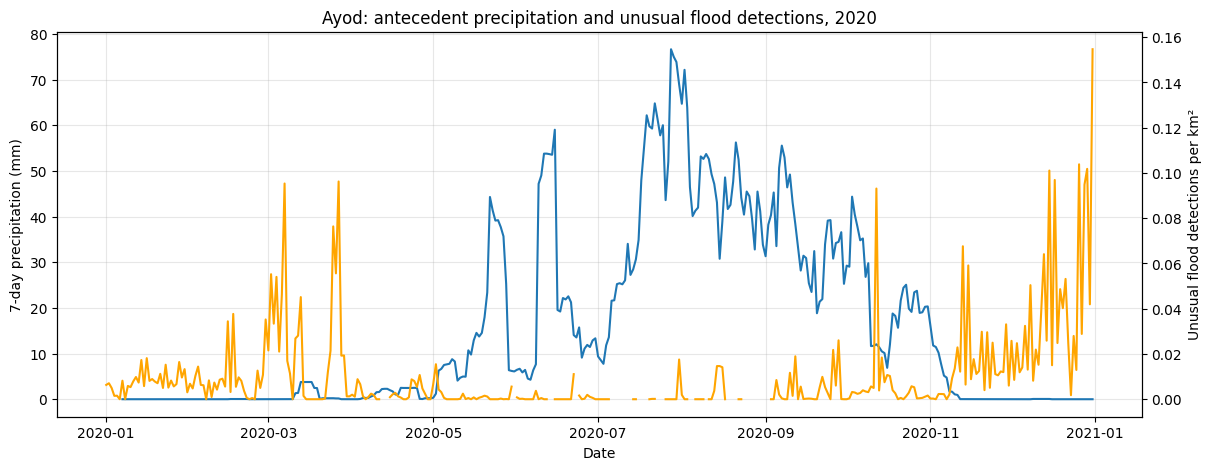

In [95]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    ayod_compare.index,
    ayod_compare["precip_7d_mm"],
    label="7-day precipitation"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("7-day precipitation (mm)")

ax2 = ax1.twinx()

ax2.plot(
    ayod_compare.index,
    ayod_compare["unusual_observations_per_km2"],
    label="Unusual flood detections",
    color="orange"
)

ax2.set_ylabel("Unusual flood detections per km²")

ax1.set_title(
    "Ayod: antecedent precipitation and unusual flood detections, 2020"
)

ax1.grid(alpha=0.3)

plt.show()

In [96]:
ayod_events = (
    ayod_compare[
        ayod_compare["unusual_observations_per_km2"] > 0
    ]
    .copy()
)

# Rank all observed unusual-flood days
top_ayod_flood_days = (
    ayod_events
    .sort_values(
        "unusual_observations_per_km2",
        ascending=False
    )
    .head(20)
)

print(
    top_ayod_flood_days[
        [
            "unusual_observations_per_km2",
            "precipitation_mm",
            "precip_3d_mm",
            "precip_7d_mm",
            "precip_14d_mm",
            "runoff_mm",
            "runoff_3d_mm",
            "runoff_7d_mm",
            "runoff_14d_mm"
        ]
    ].to_string()
)

            unusual_observations_per_km2  precipitation_mm  precip_3d_mm  precip_7d_mm  precip_14d_mm  runoff_mm  runoff_3d_mm  runoff_7d_mm  runoff_14d_mm
date                                                                                                                                                       
2020-12-31                      0.154657          0.000000      0.000000      0.000000       0.002028   0.000000      0.000000      0.000000       0.000000
2020-12-26                      0.103798          0.000000      0.000000      0.002028       0.002028   0.000000      0.000000      0.000000       0.000000
2020-12-29                      0.101791          0.000000      0.000000      0.000000       0.002028   0.000000      0.000000      0.000000       0.000000
2020-12-15                      0.101047          0.000000      0.000000      0.058572       0.058610   0.000000      0.000000      0.000108       0.000108
2020-12-17                      0.096883          0.000000      

In [50]:
# Start from Ayod's flood signal
ayod_lag_analysis = ayod_compare.copy()

# Weather variables shifted backwards:
# lag = 1 means weather from the previous day
# lag = 3 means weather ending 3 days before the flood date, etc.

for lag in [1, 3, 7, 14, 21, 30]:
    ayod_lag_analysis[f"precip_1d_before_{lag}d"] = (
        ayod_lag_analysis["precipitation_mm"].shift(lag)
    )

    ayod_lag_analysis[f"precip_7d_before_{lag}d"] = (
        ayod_lag_analysis["precip_7d_mm"].shift(lag)
    )

    ayod_lag_analysis[f"precip_14d_before_{lag}d"] = (
        ayod_lag_analysis["precip_14d_mm"].shift(lag)
    )

    ayod_lag_analysis[f"runoff_7d_before_{lag}d"] = (
        ayod_lag_analysis["runoff_7d_mm"].shift(lag)
    )

    ayod_lag_analysis[f"runoff_14d_before_{lag}d"] = (
        ayod_lag_analysis["runoff_14d_mm"].shift(lag)
    )

print(
    ayod_lag_analysis[
        [
            "unusual_observations_per_km2",
            "precip_7d_before_1d",
            "precip_7d_before_3d",
            "precip_7d_before_7d",
            "precip_14d_before_14d",
            "runoff_14d_before_14d"
        ]
    ].head(20)
)

            unusual_observations_per_km2  precip_7d_before_1d  \
date                                                            
2020-01-01                      0.006320                  NaN   
2020-01-02                      0.007064                  NaN   
2020-01-03                      0.004982                  NaN   
2020-01-04                      0.001487                  NaN   
2020-01-05                      0.001561                  NaN   
2020-01-06                      0.000000                  NaN   
2020-01-07                      0.008179                  NaN   
2020-01-08                      0.000000                  0.0   
2020-01-09                      0.005874                  0.0   
2020-01-10                      0.005353                  0.0   
2020-01-11                      0.007882                  0.0   
2020-01-12                      0.009815                  0.0   
2020-01-13                      0.007361                  0.0   
2020-01-14               

In [51]:
top_flood_dates = (
    ayod_lag_analysis[
        ayod_lag_analysis["unusual_observations_per_km2"] > 0
    ]
    .sort_values(
        "unusual_observations_per_km2",
        ascending=False
    )
    .head(20)
)

columns_to_show = [
    "unusual_observations_per_km2",
    "precip_7d_before_1d",
    "precip_7d_before_3d",
    "precip_7d_before_7d",
    "precip_14d_before_7d",
    "precip_14d_before_14d",
    "runoff_7d_before_7d",
    "runoff_14d_before_14d"
]

print(
    top_flood_dates[columns_to_show]
    .to_string()
)

            unusual_observations_per_km2  precip_7d_before_1d  precip_7d_before_3d  precip_7d_before_7d  precip_14d_before_7d  precip_14d_before_14d  runoff_7d_before_7d  runoff_14d_before_14d
date                                                                                                                                                                                            
2020-12-31                      0.154657             0.000000             0.002028             0.002028              0.002028               0.058572             0.000000               0.000108
2020-12-26                      0.103798             0.002028             0.002028             0.000000              0.058572               0.058610             0.000000               0.000108
2020-12-29                      0.101791             0.002028             0.002028             0.002028              0.060601               0.058610             0.000000               0.000108
2020-12-15                      0.1

In [52]:
ayod_analysis = ayod_lag_analysis.copy()

# Only consider days for which the flood signal is available
flood_values = ayod_analysis[
    "unusual_observations_per_km2"
]

high_flood_threshold = flood_values.quantile(0.90)

ayod_analysis["high_flood_day"] = (
    ayod_analysis["unusual_observations_per_km2"]
    >= high_flood_threshold
)

print("90th-percentile unusual-flood threshold:")
print(high_flood_threshold)

print("\nHigh-flood days:")
print(
    ayod_analysis["high_flood_day"].value_counts()
)

90th-percentile unusual-flood threshold:
0.025949602021848532

High-flood days:
high_flood_day
False    329
True      37
Name: count, dtype: int64


In [53]:
weather_columns = [
    "precip_7d_before_1d",
    "precip_7d_before_3d",
    "precip_7d_before_7d",
    "precip_14d_before_7d",
    "precip_14d_before_14d",
    "runoff_7d_before_1d",
    "runoff_7d_before_3d",
    "runoff_7d_before_7d",
    "runoff_14d_before_7d",
    "runoff_14d_before_14d"
]

high_flood_summary = (
    ayod_analysis
    .groupby("high_flood_day")[weather_columns]
    .median()
    .T
)

high_flood_summary.columns = [
    "other_days",
    "top_10pct_flood_days"
]

print(high_flood_summary)

                       other_days  top_10pct_flood_days
precip_7d_before_1d      8.419455              0.002028
precip_7d_before_3d      8.671555              0.002028
precip_7d_before_7d      9.240706              0.002028
precip_14d_before_7d    26.939981              0.043681
precip_14d_before_14d   28.092844              0.043681
runoff_7d_before_1d      0.054157              0.000000
runoff_7d_before_3d      0.057025              0.000000
runoff_7d_before_7d      0.062517              0.000000
runoff_14d_before_7d     0.245341              0.000108
runoff_14d_before_14d    0.247227              0.000021


In [54]:
high_flood_summary["difference"] = (
    high_flood_summary["top_10pct_flood_days"]
    - high_flood_summary["other_days"]
)

high_flood_summary["ratio"] = (
    high_flood_summary["top_10pct_flood_days"]
    / high_flood_summary["other_days"].replace(0, np.nan)
)

print(
    high_flood_summary.sort_values(
        "difference",
        ascending=False
    )
)

                       other_days  top_10pct_flood_days  difference     ratio
runoff_7d_before_1d      0.054157              0.000000   -0.054157  0.000000
runoff_7d_before_3d      0.057025              0.000000   -0.057025  0.000000
runoff_7d_before_7d      0.062517              0.000000   -0.062517  0.000000
runoff_14d_before_7d     0.245341              0.000108   -0.245233  0.000440
runoff_14d_before_14d    0.247227              0.000021   -0.247206  0.000087
precip_7d_before_1d      8.419455              0.002028   -8.417427  0.000241
precip_7d_before_3d      8.671555              0.002028   -8.669527  0.000234
precip_7d_before_7d      9.240706              0.002028   -9.238677  0.000220
precip_14d_before_7d    26.939981              0.043681  -26.896301  0.001621
precip_14d_before_14d   28.092844              0.043681  -28.049163  0.001555


In [55]:
daily_flood_final_2020 = daily_flood_detail.copy()

daily_flood_final_2020 = daily_flood_final_2020.merge(
    admin2[["adm2_name", "area_sqkm"]],
    on="adm2_name",
    how="left"
)

daily_flood_final_2020["unusual_observations_per_km2"] = (
    daily_flood_final_2020["unusual_observations"]
    / daily_flood_final_2020["area_sqkm"]
)

daily_flood_final_2020["recurring_observations_per_km2"] = (
    daily_flood_final_2020["recurring_observations"]
    / daily_flood_final_2020["area_sqkm"]
)

print(daily_flood_final_2020.shape)

print(
    daily_flood_final_2020[
        [
            "adm2_name",
            "date",
            "flood_observations",
            "unusual_observations",
            "recurring_observations",
            "unusual_fraction",
            "unusual_observations_per_km2"
        ]
    ].head()
)

(7231, 10)
   adm2_name       date  flood_observations  unusual_observations  \
0  Abiemnhom 2020-01-05                   1                     1   
1  Abiemnhom 2020-01-10                   1                     1   
2  Abiemnhom 2020-01-12                   4                     4   
3  Abiemnhom 2020-01-14                   4                     4   
4  Abiemnhom 2020-01-21                   2                     2   

   recurring_observations  unusual_fraction  unusual_observations_per_km2  
0                       0               1.0                      0.000415  
1                       0               1.0                      0.000415  
2                       0               1.0                      0.001661  
3                       0               1.0                      0.001661  
4                       0               1.0                      0.000831  


In [56]:
print(
    daily_flood_final_2020["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

print("\nRecords with 1–4 detected flood pixels:")
print(
    (daily_flood_final_2020["flood_observations"] < 5).sum()
)

count     7231.000000
mean       343.824506
std       1682.757442
min          1.000000
25%          5.000000
50%         29.000000
75%        142.000000
90%        550.000000
95%       1216.500000
99%       5084.700000
max      29292.000000
Name: flood_observations, dtype: float64

Records with 1–4 detected flood pixels:
1650


### Multi-year flood analysis — pilot year

The aim is to aggregate recurring and unusual flood detections to admin2 areas for each year from 2000 to 2025. Processing one year at a time reduces memory use and allows us to validate spatial assignment and aggregation before scaling up.

The flood dataset contains detected flood pixels rather than a complete record of all satellite observations. Therefore, detection counts and detection density must not be interpreted as flooded area or flood probability.

In [57]:
from processing_data.loading import load_flood_masks

pilot_year = 2000

flood_pilot = load_flood_masks(np.array([pilot_year]))

print("Shape:", flood_pilot.shape)
print("Columns:", flood_pilot.columns.tolist())
print("Date range:", flood_pilot["date"].min(), "to", flood_pilot["date"].max())
print("Unique dates:", flood_pilot["date"].nunique())
print("Tiles:", flood_pilot["tile"].nunique())
print("\nFlood type counts:")
print(flood_pilot["flood_type"].value_counts().sort_index())
print("\nMissing values:")
print(flood_pilot[["date", "lat", "lon", "tile", "flood_type"]].isna().sum())

Shape: (46963, 5)
Columns: ['date', 'lat', 'lon', 'tile', 'flood_type']
Date range: 2000-02-28 00:00:00 to 2000-12-31 00:00:00
Unique dates: 259
Tiles: 2

Flood type counts:
flood_type
0    24808
1    22155
Name: count, dtype: int64

Missing values:
date          0
lat           0
lon           0
tile          0
flood_type    0
dtype: int64


In [58]:
# Convert detected flood pixels to spatial points
flood_points_pilot = gpd.GeoDataFrame(
    flood_pilot.copy(),
    geometry=gpd.points_from_xy(
        flood_pilot["lon"],
        flood_pilot["lat"]
    ),
    crs="EPSG:4326"
)

# Assign each detection to an admin2 area
flood_with_admin2_pilot = gpd.sjoin(
    flood_points_pilot,
    admin2[["adm2_name", "geometry"]],
    how="inner",
    predicate="within"
)

print("Original detections:", len(flood_pilot))
print("Detections inside admin2:", len(flood_with_admin2_pilot))
print(
    "Share assigned to admin2:",
    round(100 * len(flood_with_admin2_pilot) / len(flood_pilot), 2),
    "%"
)
print(
    "Admin2 areas represented:",
    flood_with_admin2_pilot["adm2_name"].nunique()
)

print("\nDetections by flood type after spatial join:")
print(
    flood_with_admin2_pilot["flood_type"]
    .value_counts()
    .sort_index()
)

Original detections: 46963
Detections inside admin2: 11191
Share assigned to admin2: 23.83 %
Admin2 areas represented: 47

Detections by flood type after spatial join:
flood_type
0    2129
1    9062
Name: count, dtype: int64


In [59]:
print("Admin2 CRS:", admin2.crs)
print("Admin2 bounds (minx, miny, maxx, maxy):")
print(admin2.total_bounds)

print("\nFlood point CRS:", flood_points_pilot.crs)
print("Flood point bounds (minx, miny, maxx, maxy):")
print(flood_points_pilot.total_bounds)

print("\nDetections by tile:")
print(
    flood_pilot.groupby("tile")
    .agg(
        detections=("flood_type", "size"),
        min_lat=("lat", "min"),
        max_lat=("lat", "max"),
        min_lon=("lon", "min"),
        max_lon=("lon", "max"),
        unique_dates=("date", "nunique")
    )
)

print("\nDetections by month:")
print(
    flood_pilot.assign(month=flood_pilot["date"].dt.month)
    .groupby("month")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

Admin2 CRS: EPSG:4326
Admin2 bounds (minx, miny, maxx, maxy):
[24.15072456  3.48784008 35.95192367 12.23635188]

Flood point CRS: EPSG:4326
Flood point bounds (minx, miny, maxx, maxy):
[2.00031242e+01 1.04166672e-03 3.99260406e+01 9.89895821e+00]

Detections by tile:
        detections   min_lat   max_lat    min_lon    max_lon  unique_dates
tile                                                                      
h20v08        4977  0.094792  9.855208  20.003124  29.998959           128
h21v08       41986  0.001042  9.898958  30.001041  39.926041           254

Detections by month:
month
1         0
2      1302
3      4055
4      3752
5      3565
6      2557
7      1057
8      1359
9      4360
10     2941
11     7575
12    14440
dtype: int64


All detections: 46963
Detections inside admin2 bounding box: 12613
Share inside bounding box: 26.86 %

Tile coverage:


,all_detections,inside_bbox,inside_bbox_pct
tile,,,
h20v08,4977,3042,61.12
h21v08,41986,9571,22.80



Detections assigned to admin2 by tile:
tile
h20v08    3001
h21v08    8190
Name: assigned_detections, dtype: int64


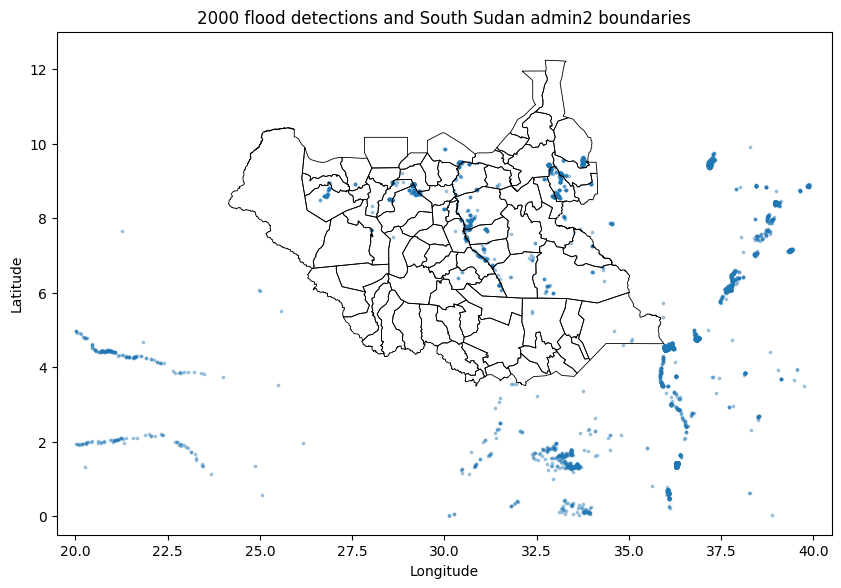

In [60]:
# Country bounding box
minx, miny, maxx, maxy = admin2.total_bounds

inside_bbox = flood_pilot[
    flood_pilot["lon"].between(minx, maxx)
    & flood_pilot["lat"].between(miny, maxy)
].copy()

print("All detections:", len(flood_pilot))
print("Detections inside admin2 bounding box:", len(inside_bbox))
print(
    "Share inside bounding box:",
    round(100 * len(inside_bbox) / len(flood_pilot), 2),
    "%"
)

# Compare tiles
tile_summary = flood_pilot.groupby("tile").size().rename("all_detections")
tile_summary = tile_summary.to_frame().join(
    inside_bbox.groupby("tile").size().rename("inside_bbox"),
    how="left"
).fillna(0)

tile_summary["inside_bbox"] = tile_summary["inside_bbox"].astype(int)
tile_summary["inside_bbox_pct"] = (
    100 * tile_summary["inside_bbox"] / tile_summary["all_detections"]
).round(2)

print("\nTile coverage:")
display(tile_summary)

# Compare with actual polygon assignment
print("\nDetections assigned to admin2 by tile:")
print(
    flood_with_admin2_pilot.groupby("tile")
    .size()
    .rename("assigned_detections")
)

# Plot a sample of detections against admin2 boundaries
sample = flood_pilot.sample(
    n=min(5000, len(flood_pilot)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(10, 8))
admin2.boundary.plot(ax=ax, linewidth=0.6, color="black")
ax.scatter(
    sample["lon"],
    sample["lat"],
    s=3,
    alpha=0.35
)
ax.set_xlim(19.5, 40.5)
ax.set_ylim(-0.5, 13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("2000 flood detections and South Sudan admin2 boundaries")
plt.show()


Inside bounding box: 12613
Assigned to admin2: 11191
Inside bounding box but not assigned: 1422

Unassigned detections by tile:
tile
h20v08      41
h21v08    1381
dtype: int64

Assigned coordinate ranges:
           lon       lat
min  26.092709  3.807292
max  35.530209  9.888541


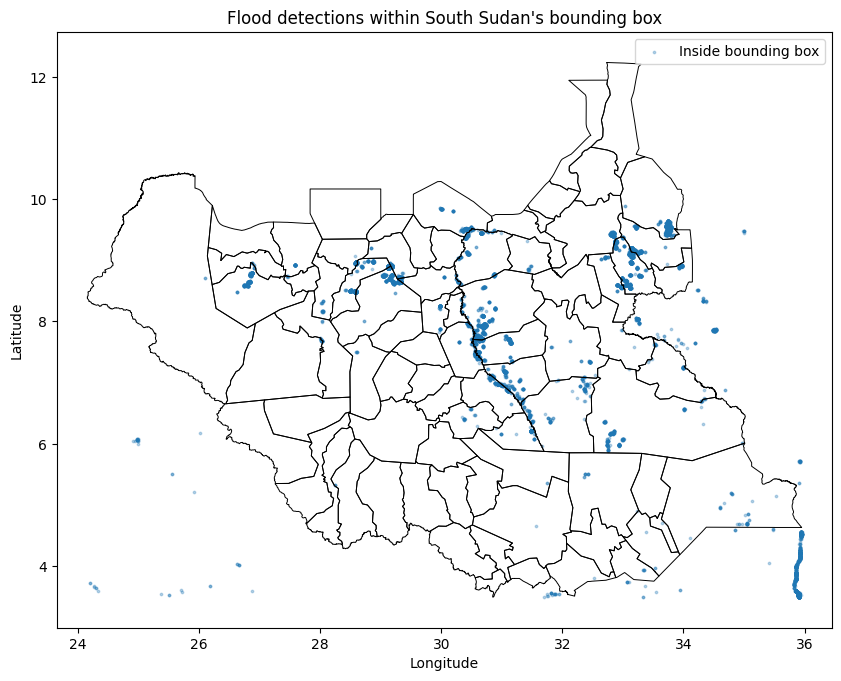

In [61]:

# Detections inside the country bounding box but not assigned
# to any admin2 polygon
assigned_indices = flood_with_admin2_pilot.index.unique()

inside_bbox_not_assigned = inside_bbox.loc[
    ~inside_bbox.index.isin(assigned_indices)
]

print("Inside bounding box:", len(inside_bbox))
print("Assigned to admin2:", len(flood_with_admin2_pilot))
print("Inside bounding box but not assigned:",
      len(inside_bbox_not_assigned))

print("\nUnassigned detections by tile:")
print(inside_bbox_not_assigned.groupby("tile").size())

# Check coordinate ranges for detections assigned to admin2
print("\nAssigned coordinate ranges:")
print(
    flood_with_admin2_pilot[["lon", "lat"]].agg(["min", "max"])
)

# Compare flood detections against the actual admin2 polygons
fig, ax = plt.subplots(figsize=(10, 8))

admin2.boundary.plot(ax=ax, linewidth=0.7, color="black")

# Show only detections within the country's bounding box
ax.scatter(
    inside_bbox["lon"],
    inside_bbox["lat"],
    s=3,
    alpha=0.3,
    label="Inside bounding box"
)

ax.set_xlim(minx - 0.5, maxx + 0.5)
ax.set_ylim(miny - 0.5, maxy + 0.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Flood detections within South Sudan's bounding box")
ax.legend()
plt.show()


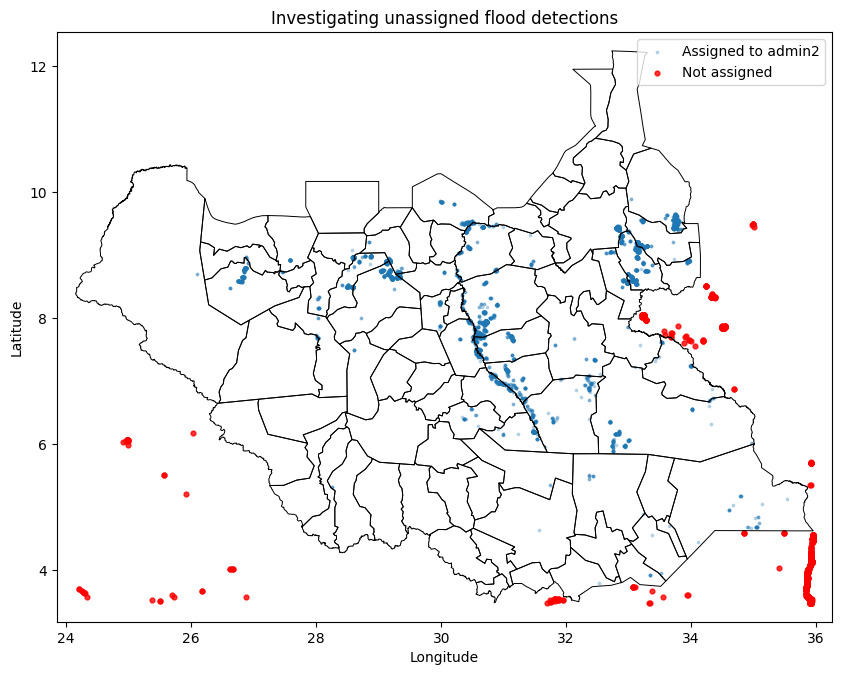

Unassigned points: 1422

Unassigned coordinates:
               lon          lat
count  1422.000000  1422.000000
mean     35.276573     4.492610
std       1.905371     1.439555
min      24.196875     3.488542
25%      35.853127     3.557292
50%      35.898960     3.980208
75%      35.921875     4.513542
max      35.951042     9.486459


In [62]:

# Identify detections that were not assigned to any admin2 polygon
assigned_indices = flood_with_admin2_pilot.index.unique()

unassigned_points = flood_points_pilot.loc[
    flood_points_pilot.index.isin(inside_bbox.index)
    & ~flood_points_pilot.index.isin(assigned_indices)
].copy()

assigned_points = flood_points_pilot.loc[
    flood_points_pilot.index.isin(assigned_indices)
    & flood_points_pilot.index.isin(inside_bbox.index)
].copy()

fig, ax = plt.subplots(figsize=(10, 8))

admin2.boundary.plot(ax=ax, linewidth=0.7, color="black")

ax.scatter(
    assigned_points["lon"],
    assigned_points["lat"],
    s=3,
    alpha=0.25,
    label="Assigned to admin2"
)

ax.scatter(
    unassigned_points["lon"],
    unassigned_points["lat"],
    s=12,
    alpha=0.8,
    color="red",
    label="Not assigned"
)

ax.set_xlim(minx - 0.3, maxx + 0.3)
ax.set_ylim(miny - 0.3, maxy + 0.3)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Investigating unassigned flood detections")
ax.legend()
plt.show()

print("Unassigned points:", len(unassigned_points))
print("\nUnassigned coordinates:")
print(unassigned_points[["lon", "lat"]].describe())


In [63]:

from pathlib import Path

flood_dir = Path("raw_data")

for path in flood_dir.rglob("*"):
    if path.is_file() and (
        "flood" in str(path).lower()
        or "h20v08" in path.name.lower()
        or "h21v08" in path.name.lower()
    ):
        print(path)


raw_data\Darthmouth Flood Observatory\100205_discharge.csv
raw_data\Darthmouth Flood Observatory\11808_discharge.csv
raw_data\Darthmouth Flood Observatory\11842_discharge.csv
raw_data\Darthmouth Flood Observatory\1505_discharge.csv
raw_data\Darthmouth Flood Observatory\1541_discharge.csv
raw_data\Darthmouth Flood Observatory\1542_discharge.csv
raw_data\Darthmouth Flood Observatory\1543_discharge.csv
raw_data\Darthmouth Flood Observatory\1544_discharge.csv
raw_data\Darthmouth Flood Observatory\1545_discharge.csv
raw_data\Darthmouth Flood Observatory\1547_discharge.csv
raw_data\Darthmouth Flood Observatory\1548_discharge.csv
raw_data\Darthmouth Flood Observatory\28546_discharge.csv
raw_data\Darthmouth Flood Observatory\information.xlsx
raw_data\flood_masks\compact_recurring\flood_events_h20v08_2000.parquet
raw_data\flood_masks\compact_recurring\flood_events_h20v08_2001.parquet
raw_data\flood_masks\compact_recurring\flood_events_h20v08_2002.parquet
raw_data\flood_masks\compact_recurring\f

In [64]:

from pathlib import Path

flood_root = Path("raw_data/flood_masks")

for tile in ["h20v07", "h21v07", "h20v08", "h21v08"]:
    files = list(flood_root.rglob(f"*{tile}*.parquet"))
    years_found = sorted({
        int(p.stem.rsplit("_", 1)[-1])
        for p in files
        if p.stem.rsplit("_", 1)[-1].isdigit()
    })

    print(
        f"{tile}: {len(files)} files; "
        f"years {min(years_found) if years_found else 'none'}"
        f"–{max(years_found) if years_found else 'none'}"
    )


h20v07: 0 files; years none–none
h21v07: 0 files; years none–none
h20v08: 52 files; years 2000–2025
h21v08: 52 files; years 2000–2025


In [65]:

import inspect
from processing_data.loading import load_flood_masks

print(inspect.getsource(load_flood_masks))


def load_flood_masks(years: np.array, bbox: dict = None) -> pd.DataFrame:
    """
    Loads the compact flood mask parquet files for all given years and both tiles (together spanning South Sudan),
    and merges the recurring and unusual flood events into a single DataFrame.

    For each (date, lat, lon) combination:
    - flood_type = 0 if recurring flood.
    - flood_type = 1 if unusual flood.
    If a pixel appears in both, unusual (1) takes priority.

    Data downloaded from:
    https://www.earthdata.nasa.gov/data/instruments/viirs/near-real-time-data/nrt-global-flood-products
    Specifically, we load post-processed 3-day flood mask MCDWD_L3_NRT data.

    The raw data is distributed in 10x10° tiles, the two tiles together span South Sudan.
    The tiles are 4800 x 4800 pixels, with pixel size of 0.0020833 degrees (~232 m at the equator). 
    It contains each location and day at which a recurring and unusual flood was detected, for the 3-day composite.

    This product sums o

In [66]:

# Approximate footprint of the supplied tiles:
# longitude 20–40 E, latitude 0–10 N
from shapely.geometry import box

supplied_tile_footprint = gpd.GeoDataFrame(
    {"name": ["supplied_tiles"]},
    geometry=[box(20, 0, 40, 10)],
    crs="EPSG:4326"
)

# Use an equal-area CRS for area calculations
admin_equal_area = admin2.to_crs("EPSG:6933")
footprint_equal_area = supplied_tile_footprint.to_crs("EPSG:6933")
footprint_geom = footprint_equal_area.geometry.iloc[0]

coverage_rows = []

for _, area in admin_equal_area.iterrows():
    total_area = area.geometry.area
    covered_area = area.geometry.intersection(footprint_geom).area

    coverage_rows.append({
        "adm2_name": area["adm2_name"],
        "area_sqkm": total_area / 1e6,
        "approx_coverage_pct": (
            100 * covered_area / total_area if total_area else np.nan
        )
    })

tile_coverage_by_area = pd.DataFrame(coverage_rows)

print("Admin2 areas with less than 100% approximate coverage:")
display(
    tile_coverage_by_area[
        tile_coverage_by_area["approx_coverage_pct"] < 99.9
    ].sort_values("approx_coverage_pct")
)

print("\nCoverage summary:")
display(
    tile_coverage_by_area["approx_coverage_pct"].describe()
)


Admin2 areas with less than 100% approximate coverage:


,adm2_name,area_sqkm,approx_coverage_pct
57,Renk,10024.098087,0.000000
54,Manyo,6679.031317,0.000000
55,Melut,6941.449726,5.062904
51,Maban,11821.219348,48.113337
48,Fashoda,3594.953375,54.283636
65,Abyei Region,10495.850579,77.536834
45,Pariang,8978.794299,78.695500
67,Raja,62010.568725,93.080231
47,Baliet,11675.847179,98.519206



Coverage summary:


count     79.000000
mean      94.370780
std       20.349653
min        0.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: approx_coverage_pct, dtype: float64

In [68]:
# Analysis period
years = np.arange(2003, 2026)

# Areas with effectively complete geometric coverage
# under the currently supplied tile footprint
FULL_COVERAGE_THRESHOLD = 99.9

fully_covered_areas = tile_coverage_by_area.loc[
    tile_coverage_by_area["approx_coverage_pct"]
    >= FULL_COVERAGE_THRESHOLD,
    "adm2_name"
].tolist()

print("Analysis years:", years[0], "-", years[-1])
print("Number of years:", len(years))
print("Areas with >=99.9% approximate coverage:",
      len(fully_covered_areas))
print("\nAreas excluded from this provisional subset:")
print(
    tile_coverage_by_area.loc[
        ~tile_coverage_by_area["adm2_name"].isin(fully_covered_areas),
        ["adm2_name", "approx_coverage_pct"]
    ].sort_values("approx_coverage_pct").to_string(index=False)
)


Analysis years: 2003 - 2025
Number of years: 23
Areas with >=99.9% approximate coverage: 70

Areas excluded from this provisional subset:
   adm2_name  approx_coverage_pct
        Renk             0.000000
       Manyo             0.000000
       Melut             5.062904
       Maban            48.113337
     Fashoda            54.283636
Abyei Region            77.536834
     Pariang            78.695500
        Raja            93.080231
      Baliet            98.519206


In [69]:

pilot_year = 2003

flood_pilot = load_flood_masks(np.array([pilot_year]))

flood_points_pilot = gpd.GeoDataFrame(
    flood_pilot.copy(),
    geometry=gpd.points_from_xy(
        flood_pilot["lon"],
        flood_pilot["lat"]
    ),
    crs="EPSG:4326"
)

flood_with_admin2_pilot = gpd.sjoin(
    flood_points_pilot,
    admin2[["adm2_name", "geometry"]],
    how="inner",
    predicate="within"
)

# Count recurring and unusual detections separately
daily_flood_pilot = (
    flood_with_admin2_pilot
    .groupby(["adm2_name", "date"])
    .agg(
        flood_observations=("flood_type", "size"),
        recurring_observations=(
            "flood_type", lambda x: (x == 0).sum()
        ),
        unusual_observations=(
            "flood_type", lambda x: (x == 1).sum()
        )
    )
    .reset_index()
)

daily_flood_pilot = daily_flood_pilot.merge(
    admin2[["adm2_name", "area_sqkm"]],
    on="adm2_name",
    how="left"
)

daily_flood_pilot["unusual_observations_per_km2"] = (
    daily_flood_pilot["unusual_observations"]
    / daily_flood_pilot["area_sqkm"]
)

daily_flood_pilot["recurring_observations_per_km2"] = (
    daily_flood_pilot["recurring_observations"]
    / daily_flood_pilot["area_sqkm"]
)

print("Year:", pilot_year)
print("Original detections:", len(flood_pilot))
print("Assigned detections:", len(flood_with_admin2_pilot))
print("Admin2 areas represented:",
      daily_flood_pilot["adm2_name"].nunique())
print("Admin2-day records:", len(daily_flood_pilot))

display(
    daily_flood_pilot[
        [
            "adm2_name",
            "date",
            "recurring_observations",
            "unusual_observations",
            "unusual_observations_per_km2"
        ]
    ].head()
)


Year: 2003
Original detections: 1056381
Assigned detections: 320552
Admin2 areas represented: 76
Admin2-day records: 5868


,adm2_name,date,recurring_observations,unusual_observations,unusual_observations_per_km2
0,Abiemnhom,2003-01-11,0,1,0.000415
1,Abiemnhom,2003-01-29,0,2,0.000831
2,Abiemnhom,2003-04-25,0,11,0.004568
3,Abiemnhom,2003-04-26,0,1,0.000415
4,Abiemnhom,2003-05-11,0,3,0.001246


In [71]:
def process_flood_year(year, admin2):
    """Load flood detections for one year and aggregate them by admin2/date."""

    flood = load_flood_masks(np.array([year]))

    if flood.empty:
        raise ValueError(f"No flood detections loaded for {year}")

    points = gpd.GeoDataFrame(
        flood.copy(),
        geometry=gpd.points_from_xy(flood["lon"], flood["lat"]),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        points,
        admin2[["adm2_name", "geometry"]],
        how="inner",
        predicate="within"
    )

    daily = (
        joined.groupby(["adm2_name", "date"])
        .agg(
            flood_observations=("flood_type", "size"),
            recurring_observations=(
                "flood_type", lambda x: (x == 0).sum()
            ),
            unusual_observations=(
                "flood_type", lambda x: (x == 1).sum()
            )
        )
        .reset_index()
    )

    daily = daily.merge(
        admin2[["adm2_name", "area_sqkm"]],
        on="adm2_name",
        how="left",
        validate="many_to_one"
    )

    daily["unusual_observations_per_km2"] = (
        daily["unusual_observations"] / daily["area_sqkm"]
    )
    daily["recurring_observations_per_km2"] = (
        daily["recurring_observations"] / daily["area_sqkm"]
    )

    # Basic checks
    assert daily[["adm2_name", "date"]].duplicated().sum() == 0
    assert (
        daily["recurring_observations"]
        + daily["unusual_observations"]
        == daily["flood_observations"]
    ).all()

    diagnostics = {
        "year": year,
        "original_detections": len(flood),
        "assigned_detections": len(joined),
        "assignment_pct": 100 * len(joined) / len(flood),
        "areas_represented": daily["adm2_name"].nunique(),
        "admin2_day_records": len(daily),
        "first_detection_date": daily["date"].min(),
        "last_detection_date": daily["date"].max()
    }

    return daily, diagnostics


In [72]:
daily_flood_2003, diagnostics_2003 = process_flood_year(
    2003, admin2
)

print(pd.Series(diagnostics_2003))
display(daily_flood_2003.head())


year                                   2003
original_detections                 1056381
assigned_detections                  320552
assignment_pct                    30.344355
areas_represented                        76
admin2_day_records                     5868
first_detection_date    2003-01-01 00:00:00
last_detection_date     2003-12-31 00:00:00
dtype: object


,adm2_name,date,flood_observations,recurring_observations,unusual_observations,area_sqkm,unusual_observations_per_km2,recurring_observations_per_km2
0,Abiemnhom,2003-01-11,1,0,1,2407.827056,0.000415,0.0
1,Abiemnhom,2003-01-29,2,0,2,2407.827056,0.000831,0.0
2,Abiemnhom,2003-04-25,11,0,11,2407.827056,0.004568,0.0
3,Abiemnhom,2003-04-26,1,0,1,2407.827056,0.000415,0.0
4,Abiemnhom,2003-05-11,3,0,3,2407.827056,0.001246,0.0


In [73]:
from pathlib import Path

output_dir = Path("processed_data/flood_daily_by_year")
output_dir.mkdir(parents=True, exist_ok=True)

diagnostics_all = []

for year in years:
    output_path = output_dir / f"flood_daily_{year}.parquet"

    # Reuse completed years if the cell is run again
    if output_path.exists():
        print(f"{year}: output already exists, skipping")
        continue

    print(f"Processing {year}...")

    daily_year, diagnostics = process_flood_year(year, admin2)

    # Save yearly results
    daily_year.to_parquet(output_path, index=False)

    diagnostics_all.append(diagnostics)

    print(
        f"  detections={diagnostics['original_detections']:,}; "
        f"assigned={diagnostics['assigned_detections']:,}; "
        f"areas={diagnostics['areas_represented']}; "
        f"admin2-days={diagnostics['admin2_day_records']:,}"
    )

# Save diagnostics for years processed in this run
if diagnostics_all:
    diagnostics_df = pd.DataFrame(diagnostics_all)
    diagnostics_path = output_dir / "processing_diagnostics_latest_run.csv"
    diagnostics_df.to_csv(diagnostics_path, index=False)
    display(diagnostics_df)


Processing 2003...
  detections=1,056,381; assigned=320,552; areas=76; admin2-days=5,868
Processing 2004...
  detections=956,384; assigned=178,611; areas=76; admin2-days=5,095
Processing 2005...
  detections=1,225,663; assigned=360,144; areas=76; admin2-days=5,537
Processing 2006...
  detections=1,331,259; assigned=691,038; areas=77; admin2-days=5,147
Processing 2007...
  detections=2,192,445; assigned=1,176,175; areas=77; admin2-days=6,562
Processing 2008...
  detections=2,026,668; assigned=1,276,495; areas=77; admin2-days=6,644
Processing 2009...
  detections=1,592,042; assigned=926,037; areas=76; admin2-days=5,587
Processing 2010...
  detections=1,397,661; assigned=499,767; areas=76; admin2-days=5,358
Processing 2011...
  detections=1,164,906; assigned=321,723; areas=76; admin2-days=4,992
Processing 2012...
  detections=1,620,212; assigned=536,219; areas=76; admin2-days=4,662
Processing 2013...
  detections=2,014,489; assigned=903,074; areas=75; admin2-days=5,246
Processing 2014...


,year,original_detections,assigned_detections,assignment_pct,areas_represented,admin2_day_records,first_detection_date,last_detection_date
0,2003,1056381,320552,30.344355,76,5868,2003-01-01,2003-12-31
1,2004,956384,178611,18.675657,76,5095,2004-01-01,2004-12-30
2,2005,1225663,360144,29.383607,76,5537,2005-01-01,2005-12-31
3,2006,1331259,691038,51.908607,77,5147,2006-01-01,2006-12-31
4,2007,2192445,1176175,53.646728,77,6562,2007-01-01,2007-12-31
5,2008,2026668,1276495,62.984909,77,6644,2008-01-01,2008-12-31
6,2009,1592042,926037,58.166619,76,5587,2009-01-01,2009-12-31
7,2010,1397661,499767,35.757383,76,5358,2010-01-01,2010-12-31
8,2011,1164906,321723,27.617937,76,4992,2011-01-01,2011-12-31
9,2012,1620212,536219,33.095607,76,4662,2012-01-01,2012-12-31


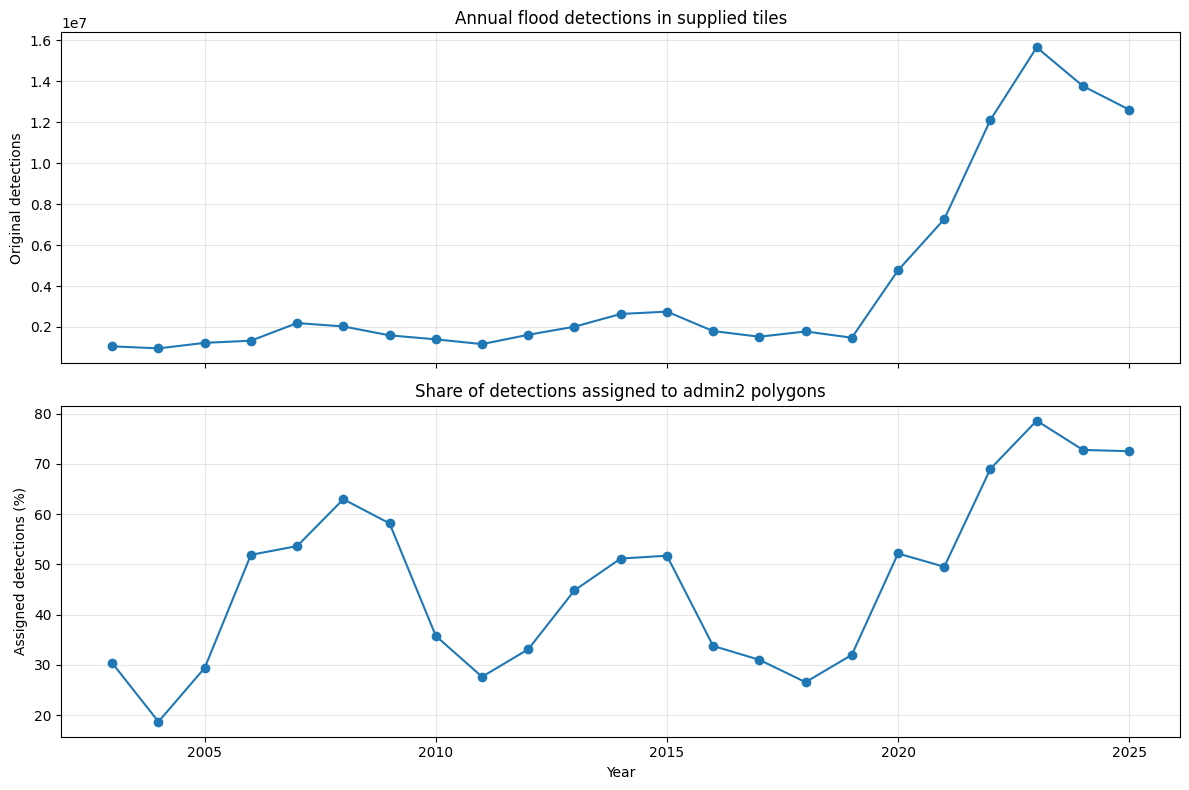

,year,original_detections,assignment_pct,areas_represented,admin2_day_records
0,2003,1056381,30.344355,76,5868
1,2004,956384,18.675657,76,5095
2,2005,1225663,29.383607,76,5537
3,2006,1331259,51.908607,77,5147
4,2007,2192445,53.646728,77,6562
5,2008,2026668,62.984909,77,6644
6,2009,1592042,58.166619,76,5587
7,2010,1397661,35.757383,76,5358
8,2011,1164906,27.617937,76,4992
9,2012,1620212,33.095607,76,4662


In [75]:
diagnostics_path = (
    Path("processed_data/flood_daily_by_year")
    / "processing_diagnostics_latest_run.csv"
)

diagnostics_df = pd.read_csv(diagnostics_path)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    diagnostics_df["year"],
    diagnostics_df["original_detections"],
    marker="o"
)
axes[0].set_ylabel("Original detections")
axes[0].set_title("Annual flood detections in supplied tiles")
axes[0].grid(alpha=0.3)

axes[1].plot(
    diagnostics_df["year"],
    diagnostics_df["assignment_pct"],
    marker="o"
)
axes[1].set_ylabel("Assigned detections (%)")
axes[1].set_xlabel("Year")
axes[1].set_title("Share of detections assigned to admin2 polygons")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(
    diagnostics_df[
        [
            "year",
            "original_detections",
            "assignment_pct",
            "areas_represented",
            "admin2_day_records"
        ]
    ]
)


In [77]:
from pathlib import Path

flood_root = Path("raw_data/flood_masks")

for folder in [
    flood_root / "compact_recurring",
    flood_root / "compact_unusual"
]:
    print(f"\nFolder: {folder}")
    files = sorted(folder.glob("*.parquet"))

    for year in [2003, 2010, 2019, 2020, 2022, 2023, 2024, 2025]:
        year_files = [
            p for p in files
            if p.stem.endswith(f"_{year}")
        ]
        print(f"{year}: {len(year_files)} files")

    if files:
        print("Example filenames:")
        for path in files[:3]:
            print(" ", path.name)



Folder: raw_data\flood_masks\compact_recurring
2003: 2 files
2010: 2 files
2019: 2 files
2020: 2 files
2022: 2 files
2023: 2 files
2024: 2 files
2025: 2 files
Example filenames:
  flood_events_h20v08_2000.parquet
  flood_events_h20v08_2001.parquet
  flood_events_h20v08_2002.parquet

Folder: raw_data\flood_masks\compact_unusual
2003: 2 files
2010: 2 files
2019: 2 files
2020: 2 files
2022: 2 files
2023: 2 files
2024: 2 files
2025: 2 files
Example filenames:
  flood_events_h20v08_2000.parquet
  flood_events_h20v08_2001.parquet
  flood_events_h20v08_2002.parquet


In [80]:
flood_root = Path("raw_data/flood_masks")

sample_files = [
    flood_root / "compact_recurring" / f"flood_events_h20v08_{year}.parquet"
    for year in [2003, 2019, 2020, 2023, 2025]
]

for path in sample_files:
    df = pd.read_parquet(path)

    print(f"\n{path.name}")
    print("Rows:", len(df))
    print("Columns:", df.columns.tolist())
    print("Data types:")
    print(df.dtypes)

    if "date" in df.columns:
        dates = pd.to_datetime(
    df["date"].astype(str),
    errors="coerce"
)
        print("Date range:", dates.min(), "to", dates.max())
        print("Unique dates:", dates.nunique())

    if {"lat", "lon"}.issubset(df.columns):
        print(
            "Latitude range:", (df["lat"].min(), df["lat"].max()),
            "| Longitude range:", (df["lon"].min(), df["lon"].max())
        )


flood_events_h20v08_2003.parquet
Rows: 165042
Columns: ['date', 'lat', 'lon', 'tile', 'cloud_frac']
Data types:
date          category
lat            float32
lon            float32
tile          category
cloud_frac     float32
dtype: object
Date range: 2003-01-01 00:00:00 to 2003-12-31 00:00:00
Unique dates: 333
Latitude range: (np.float32(0.026041666), np.float32(9.769792)) | Longitude range: (np.float32(20.001041), np.float32(29.990625))

flood_events_h20v08_2019.parquet
Rows: 134844
Columns: ['date', 'lat', 'lon', 'tile', 'cloud_frac']
Data types:
date          category
lat            float32
lon            float32
tile          category
cloud_frac     float32
dtype: object
Date range: 2019-01-01 00:00:00 to 2019-12-31 00:00:00
Unique dates: 340
Latitude range: (np.float32(0.026041666), np.float32(9.811459)) | Longitude range: (np.float32(20.001041), np.float32(29.998959))

flood_events_h20v08_2020.parquet
Rows: 373910
Columns: ['date', 'lat', 'lon', 'tile', 'cloud_frac']
Data type

In [81]:
flood_root = Path("raw_data/flood_masks")
years_to_check = [2003, 2019, 2020, 2023, 2025]

rows = []

for category in ["compact_recurring", "compact_unusual"]:
    for year in years_to_check:
        path = flood_root / category / f"flood_events_h20v08_{year}.parquet"
        df = pd.read_parquet(path)

        dates = pd.to_datetime(df["date"].astype(str), errors="coerce")

        rows.append({
            "category": category,
            "year": year,
            "rows": len(df),
            "unique_dates": dates.nunique(),
            "unique_date_lat_lon": len(
                df[["date", "lat", "lon"]].drop_duplicates()
            ),
            "cloud_frac_median": df["cloud_frac"].median(),
            "cloud_frac_missing_pct": 100 * df["cloud_frac"].isna().mean(),
        })

comparison = pd.DataFrame(rows)
display(comparison)

,category,year,rows,unique_dates,unique_date_lat_lon,cloud_frac_median,cloud_frac_missing_pct
0,compact_recurring,2003,165042,333,165042,0.0,0.0
1,compact_recurring,2019,134844,340,134844,0.0,0.0
2,compact_recurring,2020,373910,335,373910,0.0,0.0
3,compact_recurring,2023,307809,351,307809,0.0,0.0
4,compact_recurring,2025,324953,335,324953,0.0,0.0
5,compact_unusual,2003,115710,326,115710,0.0,0.0
6,compact_unusual,2019,383237,324,383237,0.0,0.0
7,compact_unusual,2020,479356,321,479356,0.0,0.0
8,compact_unusual,2023,8612689,357,8612689,0.0,0.0
9,compact_unusual,2025,3829435,348,3829435,0.0,0.0


In [82]:
years = range(2003, 2026)

records = []

for category in ["compact_recurring", "compact_unusual"]:
    for year in years:
        for tile in ["h20v08", "h21v08"]:
            path = (
                flood_root / category /
                f"flood_events_{tile}_{year}.parquet"
            )

            if not path.exists():
                records.append({
                    "category": category,
                    "year": year,
                    "tile": tile,
                    "rows": None,
                    "unique_dates": None,
                    "cloud_zero_pct": None,
                })
                continue

            df = pd.read_parquet(path)
            dates = pd.to_datetime(
                df["date"].astype(str), errors="coerce"
            )

            records.append({
                "category": category,
                "year": year,
                "tile": tile,
                "rows": len(df),
                "unique_dates": dates.nunique(),
                "cloud_zero_pct": (
                    100 * (df["cloud_frac"] == 0).mean()
                ),
            })

tile_year_counts = pd.DataFrame(records)

display(
    tile_year_counts.pivot_table(
        index="year",
        columns=["category", "tile"],
        values="rows",
        aggfunc="first"
    ).astype("Int64")
)

category compact_recurring          compact_unusual         
tile                h20v08   h21v08          h20v08   h21v08
year                                                        
2003                165042   516435          115710   259194
2004                 70929   620903           37647   226905
2005                 83513   653375           81981   406794
2006                121203   493808          123069   593179
2007                252723   702919          318163   918640
2008                342518   554935          544318   584897
2009                169231   486407          113589   822815
2010                172718   660478          106657   457808
2011                133256   570981           45475   415194
2012                 79554   781089           43763   715806
2013                184850   864255          308658   656726
2014                276458   948577          659612   751144
2015                209770   955639          387244  1197161
2016                174713   967315           88432   571348
2017                144054   875179           36628   469740
2018                156635  1018969           52386   554074
2019                134844   822835          383237   136407
2020                373910  1285618          479356  2626160
2021                394303  1386373          696180  4788279
2022                447615  1200558         4360625  6101559
2023                307809  1223908         8612689  5502608
2024                477807  1297157         5858909  6125556
2025                324953   991540         3829435  7461487

In [83]:
for year in [2019, 2020, 2023, 2025]:
    path = (
        flood_root / "compact_unusual" /
        f"flood_events_h20v08_{year}.parquet"
    )
    df = pd.read_parquet(path)

    print(f"\n{year}")
    print(df["cloud_frac"].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]
    ))


2019
count    383237.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
90%           0.0
99%           0.0
max           0.0
Name: cloud_frac, dtype: float64

2020
count    479356.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
90%           0.0
99%           0.0
max           0.0
Name: cloud_frac, dtype: float64

2023
count    8612689.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
90%            0.0
99%            0.0
max            0.0
Name: cloud_frac, dtype: float64

2025
count    3829435.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
90%            0.0
99%            0.0
max            0.0
Name: cloud_frac, dtype: float64


In [84]:
daily_counts = []

for category in ["compact_recurring", "compact_unusual"]:
    for year in range(2003, 2026):
        for tile in ["h20v08", "h21v08"]:
            path = (
                flood_root / category /
                f"flood_events_{tile}_{year}.parquet"
            )

            if not path.exists():
                continue

            df = pd.read_parquet(path)
            df["date"] = pd.to_datetime(df["date"].astype(str))

            counts = df.groupby("date").size()

            daily_counts.append({
                "category": category,
                "year": year,
                "tile": tile,
                "median_records_per_date": counts.median(),
                "mean_records_per_date": counts.mean(),
                "p95_records_per_date": counts.quantile(0.95),
                "max_records_per_date": counts.max(),
            })

daily_summary = pd.DataFrame(daily_counts)

display(
    daily_summary[
        daily_summary["year"].isin([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
    ].sort_values(["category", "tile", "year"])
)

,category,year,tile,median_records_per_date,mean_records_per_date,p95_records_per_date,max_records_per_date
30,compact_recurring,2018,h20v08,97.0,455.334302,2713.15,4975
32,compact_recurring,2019,h20v08,67.0,396.600000,2264.45,5294
34,compact_recurring,2020,h20v08,202.0,1116.149254,4494.70,10056
36,compact_recurring,2021,h20v08,294.0,1170.038576,4764.20,7294
38,compact_recurring,2022,h20v08,268.0,1394.439252,5883.00,9810
40,compact_recurring,2023,h20v08,151.0,876.948718,4246.00,6257
42,compact_recurring,2024,h20v08,292.0,1376.965418,5215.20,6848
44,compact_recurring,2025,h20v08,143.0,970.008955,3972.00,6073
31,compact_recurring,2018,h21v08,2810.0,2791.695890,5252.20,7690
33,compact_recurring,2019,h21v08,2044.0,2273.024862,4904.05,7438


In [85]:
# Quick check of the 2020 unusual-detection series
daily_check = daily_flood_detail.copy()
daily_check["date"] = pd.to_datetime(daily_check["date"])

print("Date range:")
print(daily_check["date"].min(), "to", daily_check["date"].max())

print("\nNumber of areas:", daily_check["adm2_name"].nunique())
print("Number of area-day records:", len(daily_check))

print("\nUnusual detections per area-day:")
print(
    daily_check["unusual_observations"]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
)

print(
    "\nShare of recorded area-days with unusual detections:",
    f"{(daily_check['unusual_observations'] > 0).mean():.1%}"
)

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Number of areas: 77
Number of area-day records: 7231

Unusual detections per area-day:
count     7231.000000
mean       284.289863
std       1637.793760
min          0.000000
50%         15.000000
75%         87.000000
90%        361.000000
95%        867.000000
99%       4557.000000
max      29058.000000
Name: unusual_observations, dtype: float64

Share of recorded area-days with unusual detections: 91.1%


In [86]:
# Build a cautious 2020 admin2-day panel
all_dates = pd.date_range("2020-01-01", "2020-12-31", freq="D")
all_areas = sorted(admin2["adm2_name"].unique())

# Dates on which the flood product has at least one record anywhere
dates_with_detections = pd.DatetimeIndex(
    daily_flood_detail.loc[
        daily_flood_detail["flood_observations"] > 0, "date"
    ].unique()
)

# Complete panel only for dates with evidence of product detections
panel_index = pd.MultiIndex.from_product(
    [all_areas, dates_with_detections],
    names=["adm2_name", "date"]
)

daily_panel = (
    daily_flood_detail
    .set_index(["adm2_name", "date"])
    .reindex(panel_index)
    .reset_index()
)

count_cols = [
    "flood_observations",
    "recurring_observations",
    "unusual_observations"
]

daily_panel[count_cols] = daily_panel[count_cols].fillna(0)

print("All admin2 areas:", len(all_areas))
print("Calendar days in 2020:", len(all_dates))
print("Dates with any detections:", len(dates_with_detections))
print("Area-days in cautious panel:", len(daily_panel))
print(
    "Unusual-positive area-days:",
    (daily_panel["unusual_observations"] > 0).sum()
)
print(
    "Unusual-positive share of panel:",
    f"{(daily_panel['unusual_observations'] > 0).mean():.1%}"
)

All admin2 areas: 79
Calendar days in 2020: 366
Dates with any detections: 331
Area-days in cautious panel: 26149
Unusual-positive area-days: 6584
Unusual-positive share of panel: 25.2%
